In [5]:
import h5py
import os

folder_path = '/Users/omagarwal/Downloads/INSAT_DATA'

for file in sorted(os.listdir(folder_path)):
    if file.endswith('.h5') or file.endswith('.hdf5'):
        path = os.path.join(folder_path, file)
        try:
            with h5py.File(path, 'r') as f:
                if 'IMG_TIR1_TEMP' in f:
                    data = f['IMG_TIR1_TEMP'][()]
                    print(f"{file}: ✅ Found 'IMG_TIR1_TEMP', shape = {data.shape}, dtype = {data.dtype}")
                else:
                    print(f"{file}: ❌ 'IMG_TIR1_TEMP' not found.")
        except Exception as e:
            print(f"{file}: ❌ Error reading file -> {e}")

3RIMG_01MAR2025_1215_L1B_STD_V01R00.h5: ✅ Found 'IMG_TIR1_TEMP', shape = (1024,), dtype = float32
3RIMG_01MAR2025_1245_L1B_STD_V01R00.h5: ✅ Found 'IMG_TIR1_TEMP', shape = (1024,), dtype = float32
3RIMG_02MAR2025_1215_L1B_STD_V01R00.h5: ✅ Found 'IMG_TIR1_TEMP', shape = (1024,), dtype = float32
3RIMG_02MAR2025_1245_L1B_STD_V01R00.h5: ✅ Found 'IMG_TIR1_TEMP', shape = (1024,), dtype = float32
3RIMG_03MAR2025_1215_L1B_STD_V01R00.h5: ✅ Found 'IMG_TIR1_TEMP', shape = (1024,), dtype = float32
3RIMG_03MAR2025_1245_L1B_STD_V01R00.h5: ✅ Found 'IMG_TIR1_TEMP', shape = (1024,), dtype = float32
3RIMG_04MAR2025_1215_L1B_STD_V01R00.h5: ✅ Found 'IMG_TIR1_TEMP', shape = (1024,), dtype = float32
3RIMG_04MAR2025_1245_L1B_STD_V01R00.h5: ✅ Found 'IMG_TIR1_TEMP', shape = (1024,), dtype = float32
3RIMG_05MAR2025_1215_L1B_STD_V01R00.h5: ✅ Found 'IMG_TIR1_TEMP', shape = (1024,), dtype = float32
3RIMG_05MAR2025_1245_L1B_STD_V01R00.h5: ✅ Found 'IMG_TIR1_TEMP', shape = (1024,), dtype = float32
3RIMG_06MAR2025_1215

In [7]:
# Cell 1: Import necessary libraries
import os
import h5py
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
import joblib
import warnings
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
import matplotlib.dates as mdates
from matplotlib.colors import LinearSegmentedColormap
import calendar
from scipy import stats

# For interactive plotting
try:
    import plotly.express as px
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    plotly_available = True
except ImportError:
    print("Plotly not available. Interactive plots will be skipped.")
    plotly_available = False

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Set some nice plotting styles
plt.style.use('seaborn-v0_8-whitegrid')
colors = sns.color_palette("viridis", 8)
sns.set_palette(colors)

print("Libraries imported successfully!")

Libraries imported successfully!


In [9]:
# Cell 2: Define the data extraction functions
def extract_bt_data(file_path):
    """Extract brightness temperature data from an H5 file"""
    try:
        with h5py.File(file_path, 'r') as f:
            # Check if the expected dataset exists
            if 'IMG_TIR1_TEMP' not in f:
                print(f"Warning: 'IMG_TIR1_TEMP' not found in {file_path}. Available keys: {list(f.keys())}")
                return None, None
                
            bt_data = f['IMG_TIR1_TEMP'][:]
            
            # Calculate various statistics
            median_bt = np.nanmedian(bt_data)
            mean_bt = np.nanmean(bt_data)
            min_bt = np.nanmin(bt_data)
            max_bt = np.nanmax(bt_data)
            std_bt = np.nanstd(bt_data)
            
            # Calculate percentiles
            p10 = np.nanpercentile(bt_data, 10)
            p25 = np.nanpercentile(bt_data, 25)
            p75 = np.nanpercentile(bt_data, 75)
            p90 = np.nanpercentile(bt_data, 90)
            
            # Extract spatial information (if available)
            spatial_stats = {}
            if bt_data.ndim >= 2:
                # Get center region and corner regions stats
                h, w = bt_data.shape[:2]
                center = bt_data[h//4:3*h//4, w//4:3*w//4]
                
                spatial_stats = {
                    'center_median': np.nanmedian(center),
                    'north_median': np.nanmedian(bt_data[:h//4, :]),
                    'south_median': np.nanmedian(bt_data[3*h//4:, :]),
                    'east_median': np.nanmedian(bt_data[:, 3*w//4:]),
                    'west_median': np.nanmedian(bt_data[:, :w//4])
                }
            
            # Get timestamp from filename
            timestamp = get_datetime_from_filename(os.path.basename(file_path))
            
            return timestamp, {
                'median': median_bt,
                'mean': mean_bt,
                'min': min_bt,
                'max': max_bt,
                'std': std_bt,
                'p10': p10,
                'p25': p25,
                'p75': p75,
                'p90': p90,
                **spatial_stats
            }
            
    except Exception as e:
        print(f"❌ Error processing {file_path}: {e}")
        return None, None

def get_datetime_from_filename(filename):
    """Extract datetime from filename pattern"""
    try:
        parts = filename.split('_')
        date_str = parts[1]  # e.g., 01MAR2025
        time_str = parts[2]  # e.g., 1215
        
        # Try to parse the datetime
        dt = datetime.strptime(date_str + time_str, "%d%b%Y%H%M")
        return dt
    except Exception as e:
        print(f"❌ Error parsing datetime from {filename}: {e}")
        return None

def load_all_bt(folder):
    """Load all brightness temperature data from the folder"""
    data = []
    
    print(f"🔍 Scanning folder: {folder}")
    files = [f for f in sorted(os.listdir(folder)) if f.endswith('.h5')]
    
    if not files:
        print("❌ No H5 files found in the specified folder.")
        return pd.DataFrame()
        
    print(f"📊 Found {len(files)} H5 files to process")
    
    for file in files:
        dt, bt_stats = extract_bt_data(os.path.join(folder, file))
        if dt and bt_stats:
            row = {'DateTime': dt, **{f'BT_{k}': v for k, v in bt_stats.items()}}
            data.append(row)
            
    df = pd.DataFrame(data)
    
    print(f"✅ Successfully processed {len(df)} files")
    return df

# Define the folder path - adjust as needed
folder_path = "/Users/omagarwal/Downloads/INSAT_DATA"  


In [11]:
# Cell 3: Load the data
# Load all brightness temperature data
bt_df = load_all_bt(folder_path)

# Display the first few rows to inspect the data
if not bt_df.empty:
    print(f"Data loaded successfully with {len(bt_df)} rows and {len(bt_df.columns)} columns")
    display(bt_df.head())
    
    # Basic statistics
    print("\nBasic statistics of median brightness temperature:")
    display(bt_df['BT_median'].describe())
else:
    print("No data was loaded. Please check the folder path.")


🔍 Scanning folder: /Users/omagarwal/Downloads/INSAT_DATA
📊 Found 60 H5 files to process
✅ Successfully processed 60 files
Data loaded successfully with 60 rows and 10 columns


,DateTime,BT_median,BT_mean,BT_min,BT_max,BT_std,BT_p10,BT_p25,BT_p75,BT_p90
0,2025-03-01 12:15:00,293.782837,279.774170,179.859482,338.918640,49.033058,186.585422,249.738205,320.481590,332.308450
1,2025-03-01 12:45:00,293.892700,279.881836,179.859482,339.069336,49.062893,186.746289,249.834682,320.611099,332.450543
2,2025-03-02 12:15:00,293.782837,279.774170,179.859482,338.918640,49.033058,186.585422,249.738205,320.481590,332.308450
3,2025-03-02 12:45:00,293.892700,279.881836,179.859482,339.069336,49.062893,186.746289,249.834682,320.611099,332.450543
4,2025-03-03 12:15:00,293.819519,279.810120,179.859482,338.968933,49.043007,186.639226,249.770428,320.524811,332.355865



Basic statistics of median brightness temperature:


count     60.000000
mean     293.761841
std        0.197499
min      293.225708
25%      293.773651
50%      293.819519
75%      293.892700
max      293.965698
Name: BT_median, dtype: float64

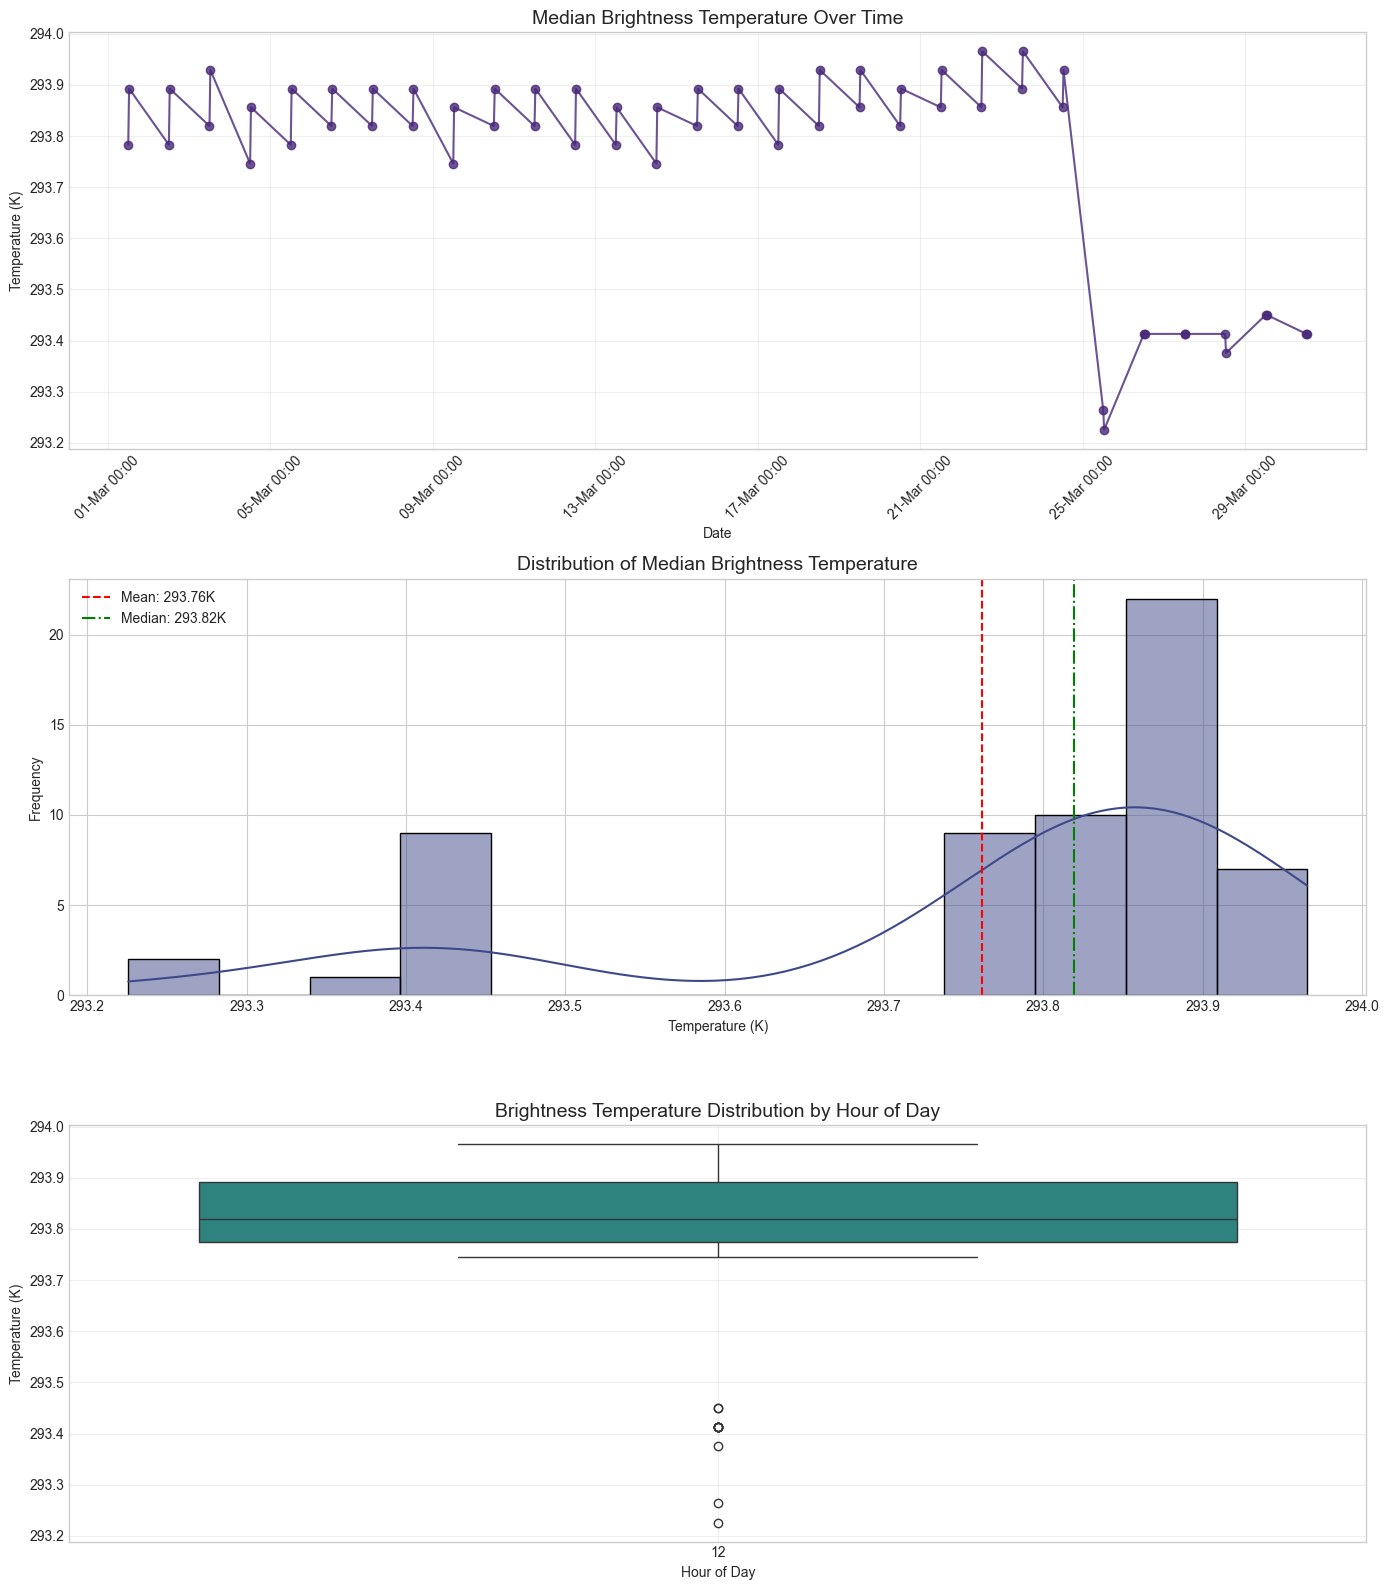

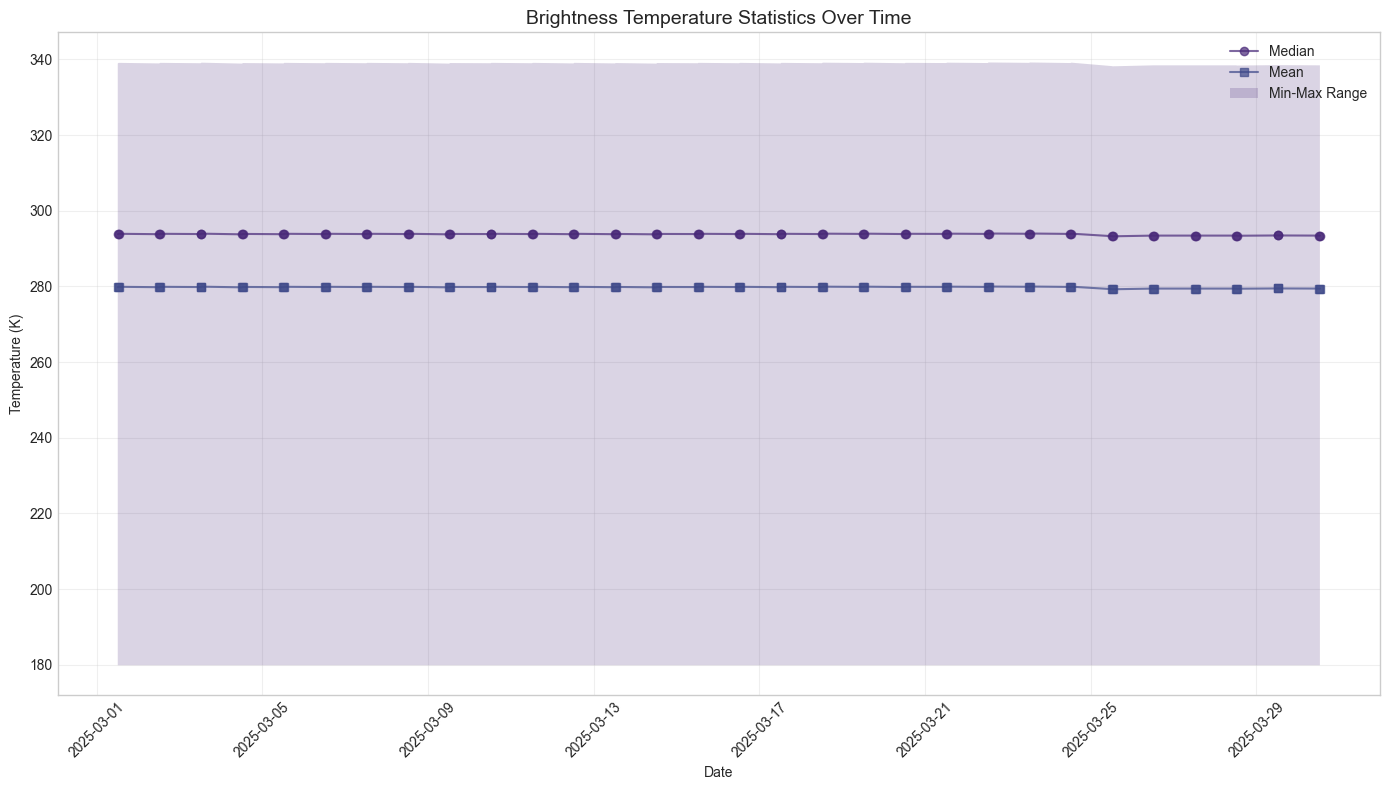

In [13]:
# Cell 4: Initial data exploration and visualization
if not bt_df.empty:
    # Set up the figure layout
    fig, axes = plt.subplots(3, 1, figsize=(14, 16))
    
    # Plot 1: Time series of median brightness temperature
    axes[0].plot(bt_df['DateTime'], bt_df['BT_median'], 'o-', color=colors[0], alpha=0.8)
    axes[0].set_title('Median Brightness Temperature Over Time', fontsize=14)
    axes[0].set_xlabel('Date')
    axes[0].set_ylabel('Temperature (K)')
    axes[0].grid(True, alpha=0.3)
    
    # Format x-axis date labels nicely
    axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%d-%b %H:%M'))
    plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)
    
    # Plot 2: Distribution of median brightness temperature
    sns.histplot(bt_df['BT_median'], kde=True, ax=axes[1], color=colors[1])
    axes[1].set_title('Distribution of Median Brightness Temperature', fontsize=14)
    axes[1].set_xlabel('Temperature (K)')
    axes[1].set_ylabel('Frequency')
    
    # Add vertical lines for mean and median
    mean_temp = bt_df['BT_median'].mean()
    median_temp = bt_df['BT_median'].median()
    axes[1].axvline(mean_temp, color='red', linestyle='--', label=f'Mean: {mean_temp:.2f}K')
    axes[1].axvline(median_temp, color='green', linestyle='-.', label=f'Median: {median_temp:.2f}K')
    axes[1].legend()
    
    # Plot 3: Box plot by hour of day to see daily patterns
    bt_df['Hour'] = bt_df['DateTime'].dt.hour
    sns.boxplot(x='Hour', y='BT_median', data=bt_df, ax=axes[2], palette='viridis')
    axes[2].set_title('Brightness Temperature Distribution by Hour of Day', fontsize=14)
    axes[2].set_xlabel('Hour of Day')
    axes[2].set_ylabel('Temperature (K)')
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Additional plot: Comparing mean, median, min, max over time
    plt.figure(figsize=(14, 8))
    plt.plot(bt_df['DateTime'], bt_df['BT_median'], 'o-', label='Median', alpha=0.7)
    plt.plot(bt_df['DateTime'], bt_df['BT_mean'], 's-', label='Mean', alpha=0.7)
    plt.fill_between(bt_df['DateTime'], bt_df['BT_min'], bt_df['BT_max'], 
                    alpha=0.2, label='Min-Max Range')
    
    plt.title('Brightness Temperature Statistics Over Time', fontsize=14)
    plt.xlabel('Date')
    plt.ylabel('Temperature (K)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [15]:
# Cell 5: Feature engineering
def engineer_features(df):
    """Create features for machine learning from the brightness temperature data"""
    # Make a copy to avoid modifying the original
    df_fe = df.copy()
    
    # Make sure data is sorted by datetime
    df_fe = df_fe.sort_values("DateTime").reset_index(drop=True)
    
    # Basic datetime features
    df_fe["Year"] = df_fe["DateTime"].dt.year
    df_fe["Month"] = df_fe["DateTime"].dt.month
    df_fe["Day"] = df_fe["DateTime"].dt.day
    df_fe["DayOfYear"] = df_fe["DateTime"].dt.dayofyear
    df_fe["Hour"] = df_fe["DateTime"].dt.hour
    df_fe["Minute"] = df_fe["DateTime"].dt.minute
    df_fe["HourDecimal"] = df_fe["Hour"] + df_fe["Minute"] / 60.0
    df_fe["DayOfWeek"] = df_fe["DateTime"].dt.dayofweek
    df_fe["IsWeekend"] = df_fe["DayOfWeek"].apply(lambda x: 1 if x >= 5 else 0)
    
    # Time of day categorical
    df_fe["TimeOfDay"] = pd.cut(
        df_fe["HourDecimal"],
        bins=[0, 6, 12, 18, 24],
        labels=["Night", "Morning", "Afternoon", "Evening"]
    )
    
    # Cyclical encoding for time features to preserve continuity
    df_fe["Hour_sin"] = np.sin(2 * np.pi * df_fe["Hour"] / 24)
    df_fe["Hour_cos"] = np.cos(2 * np.pi * df_fe["Hour"] / 24)
    df_fe["DayOfYear_sin"] = np.sin(2 * np.pi * df_fe["DayOfYear"] / 365)
    df_fe["DayOfYear_cos"] = np.cos(2 * np.pi * df_fe["DayOfYear"] / 365)
    
    # Lag features for median brightness temperature
    for i in range(1, 5):
        df_fe[f"BT_median_Lag{i}"] = df_fe["BT_median"].shift(i)
        
    # Rolling statistics
    for window in [3, 6, 12, 24]:
        df_fe[f"BT_median_Rolling_Mean_{window}h"] = df_fe["BT_median"].rolling(window=window).mean()
        df_fe[f"BT_median_Rolling_Std_{window}h"] = df_fe["BT_median"].rolling(window=window).std()
        df_fe[f"BT_median_Rolling_Min_{window}h"] = df_fe["BT_median"].rolling(window=window).min()
        df_fe[f"BT_median_Rolling_Max_{window}h"] = df_fe["BT_median"].rolling(window=window).max()
    
    # Difference features
    df_fe["BT_median_Diff"] = df_fe["BT_median"].diff()
    df_fe["BT_median_Diff2"] = df_fe["BT_median_Diff"].diff()
    
    # Temperature variability features
    if "BT_std" in df_fe.columns:
        df_fe["BT_variability_ratio"] = df_fe["BT_std"] / df_fe["BT_median"]
        df_fe["BT_range"] = df_fe["BT_max"] - df_fe["BT_min"]
        df_fe["BT_IQR"] = df_fe["BT_p75"] - df_fe["BT_p25"]
    
    # Daily patterns - hours from midnight
    df_fe["HoursFromMidnight"] = df_fe["Hour"] + df_fe["Minute"] / 60.0
    df_fe["HoursFromNoon"] = np.abs(df_fe["HourDecimal"] - 12)
    
    # Day/Night indicator (simple version)
    df_fe["IsDaytime"] = ((df_fe["Hour"] >= 6) & (df_fe["Hour"] < 18)).astype(int)
    
    # Drop rows with NaN values created by rolling and lag features
    print(f"Before dropping NaNs: {len(df_fe)} rows")
    df_fe = df_fe.dropna()
    print(f"After dropping NaNs: {len(df_fe)} rows")
    
    return df_fe

# Create engineered features
bt_df_fe = engineer_features(bt_df)

# Display the engineered features
print(f"Engineered dataset has {len(bt_df_fe)} rows and {len(bt_df_fe.columns)} columns")
display(bt_df_fe.head())

Before dropping NaNs: 60 rows
After dropping NaNs: 37 rows
Engineered dataset has 37 rows and 52 columns


,DateTime,BT_median,BT_mean,BT_min,BT_max,BT_std,BT_p10,BT_p25,BT_p75,BT_p90,...,BT_median_Rolling_Min_24h,BT_median_Rolling_Max_24h,BT_median_Diff,BT_median_Diff2,BT_variability_ratio,BT_range,BT_IQR,HoursFromMidnight,HoursFromNoon,IsDaytime
23,2025-03-12 12:45:00,293.892700,279.881836,179.859482,339.069336,49.062893,186.746289,249.834682,320.611099,332.450543,...,293.746094,293.929199,0.109863,0.219727,0.166942,159.209854,70.776417,12.75,0.75,1
24,2025-03-13 12:15:00,293.782837,279.774170,179.859482,338.918640,49.033058,186.585422,249.738205,320.481590,332.308450,...,293.746094,293.929199,-0.109863,-0.219727,0.166902,159.059158,70.743385,12.25,0.25,1
25,2025-03-13 12:45:00,293.856110,279.846008,179.859482,339.019165,49.052952,186.692836,249.802578,320.568001,332.403241,...,293.746094,293.929199,0.073273,0.183136,0.166928,159.159683,70.765423,12.75,0.75,1
26,2025-03-14 12:15:00,293.746094,279.738220,179.859482,338.868286,49.023113,186.531424,249.705944,320.438309,332.260974,...,293.746094,293.929199,-0.110016,-0.183289,0.166889,159.008804,70.732365,12.25,0.25,1
27,2025-03-14 12:45:00,293.856110,279.846008,179.859482,339.019165,49.052952,186.692836,249.802578,320.568001,332.403241,...,293.746094,293.929199,0.110016,0.220032,0.166928,159.159683,70.765423,12.75,0.75,1


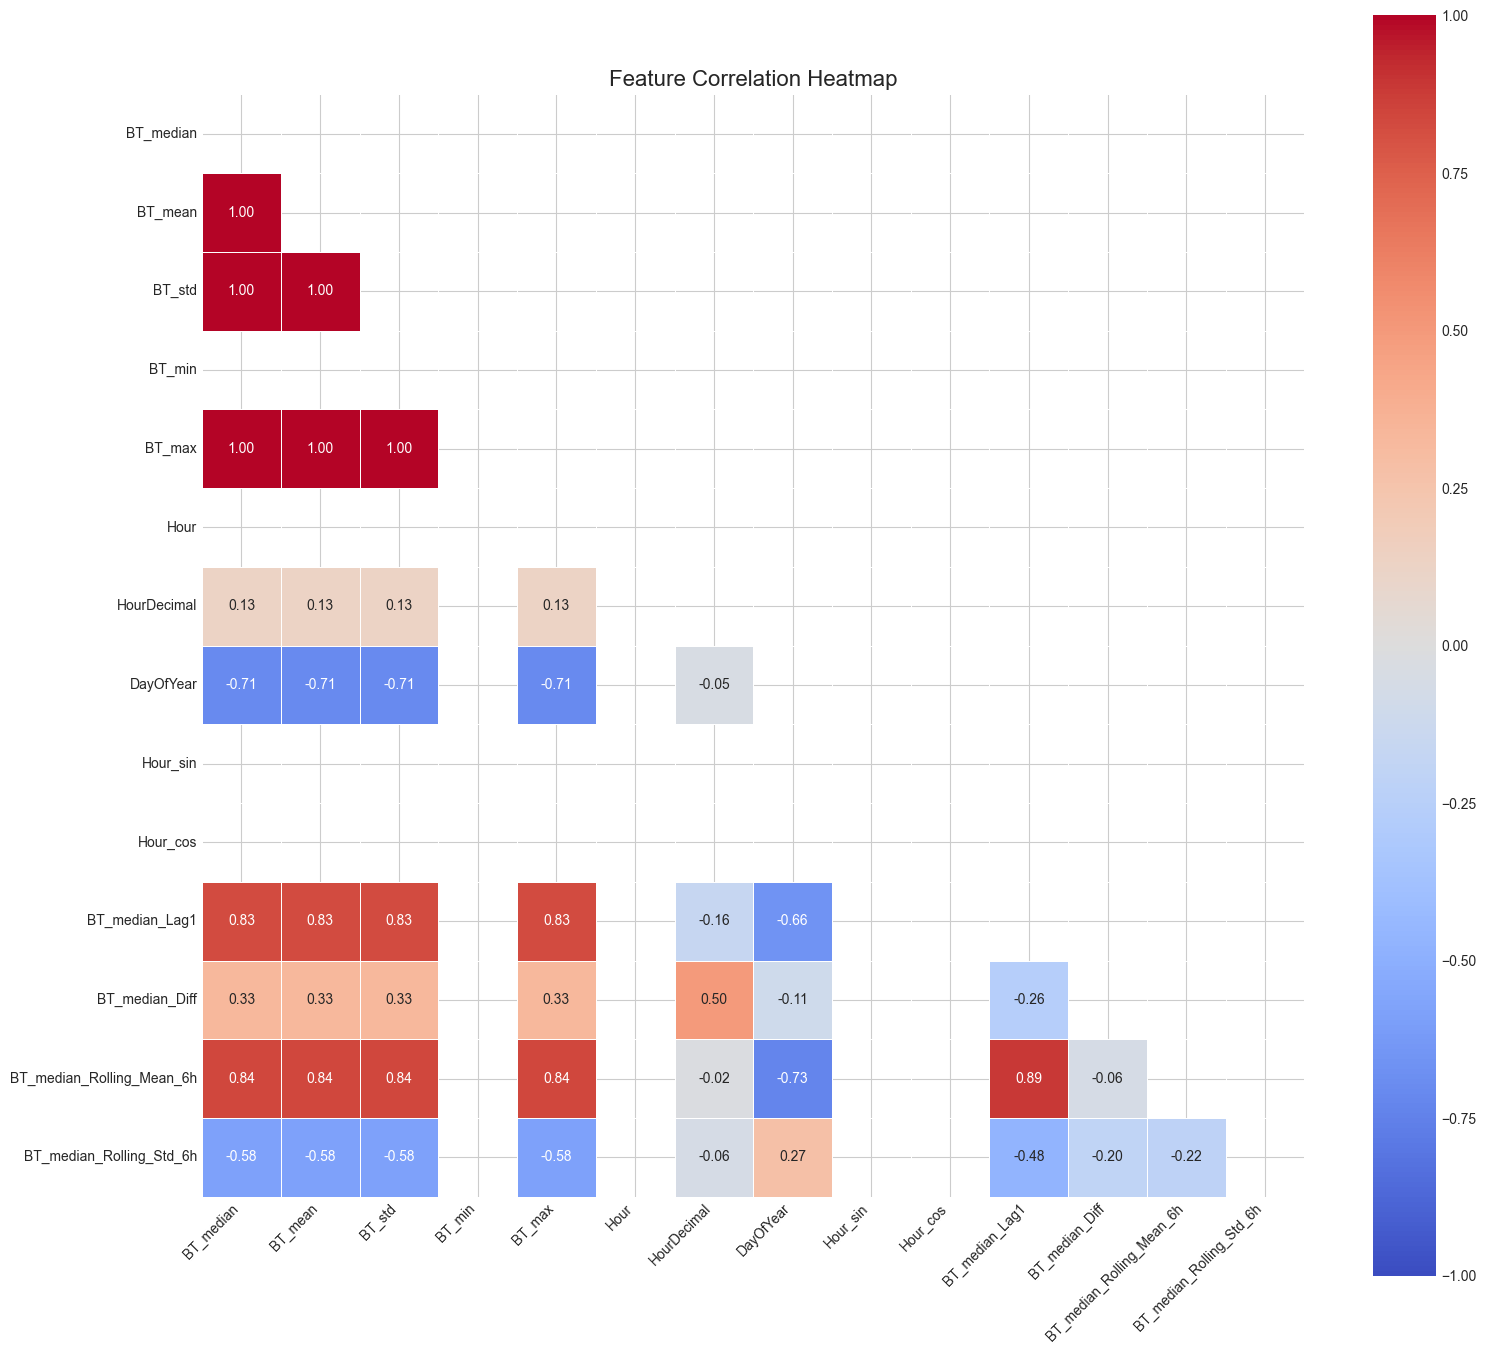

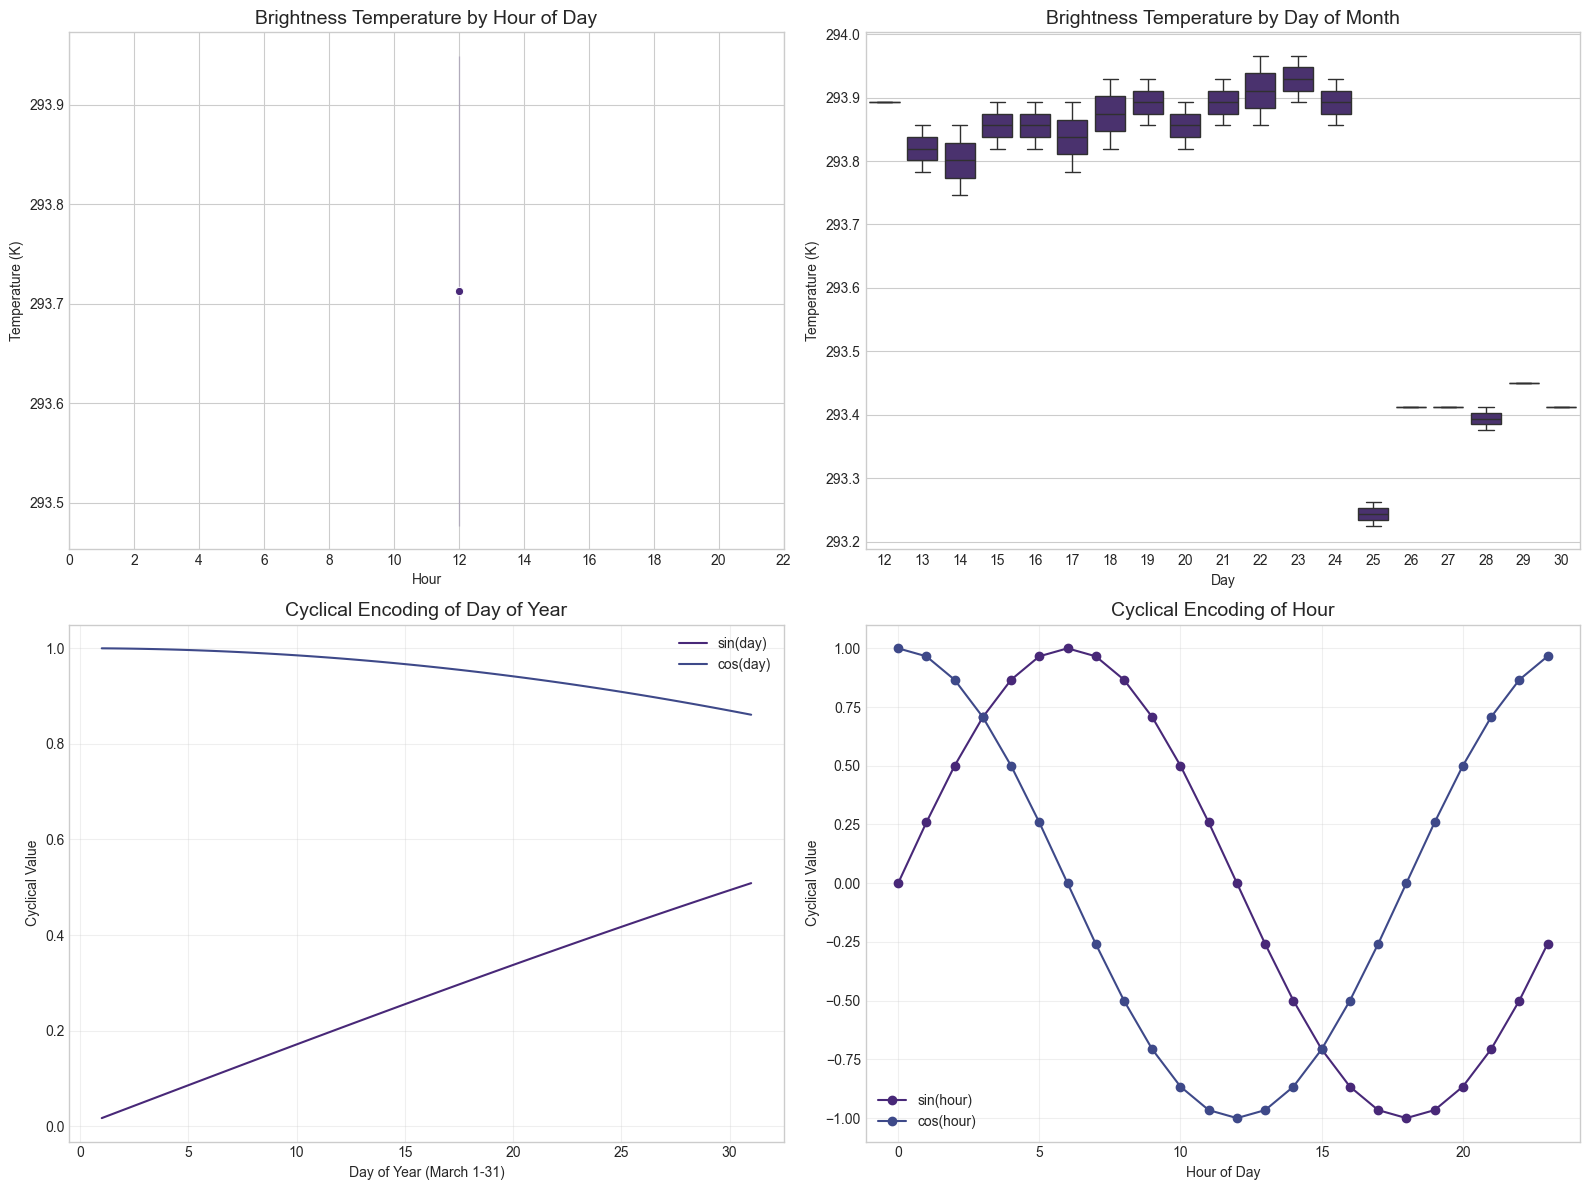

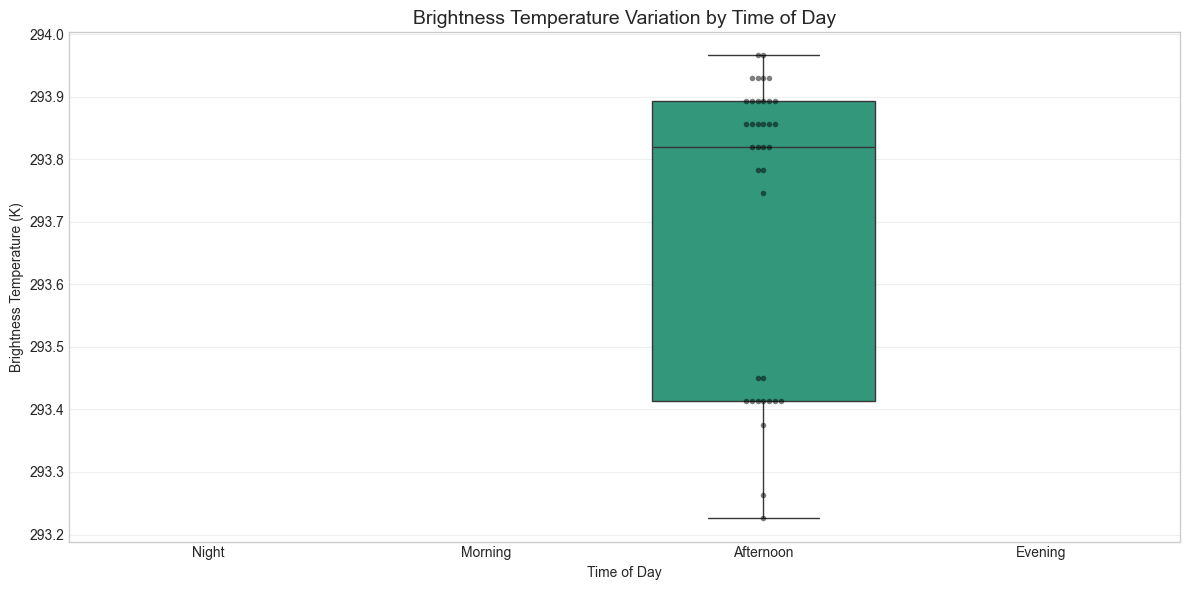

In [17]:
# Cell 6: Explore engineered features with visualizations
if not bt_df_fe.empty:
    # Feature correlation heatmap
    plt.figure(figsize=(16, 14))
    
    # Select numeric columns for correlation analysis
    numeric_cols = bt_df_fe.select_dtypes(include=['number']).columns
    
    # Filter out highly correlated features for better visualization
    # Select key features for a cleaner heatmap
    key_features = ['BT_median', 'BT_mean', 'BT_std', 'BT_min', 'BT_max', 
                   'Hour', 'HourDecimal', 'DayOfYear', 'Hour_sin', 'Hour_cos',
                   'BT_median_Lag1', 'BT_median_Diff', 
                   'BT_median_Rolling_Mean_6h', 'BT_median_Rolling_Std_6h']
    
    # Ensure all selected features exist in the dataframe
    key_features = [f for f in key_features if f in bt_df_fe.columns]
    
    # Calculate and plot correlation matrix
    corr_matrix = bt_df_fe[key_features].corr()
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', annot=True, fmt='.2f', 
               vmin=-1, vmax=1, center=0, square=True, linewidths=.5)
    
    plt.title('Feature Correlation Heatmap', fontsize=16)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    
    # Visualize time-based patterns
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Plot 1: Hour of day vs BT
    sns.lineplot(x='Hour', y='BT_median', data=bt_df_fe, 
                ci='sd', err_style='band', ax=axes[0, 0], marker='o')
    axes[0, 0].set_title('Brightness Temperature by Hour of Day', fontsize=14)
    axes[0, 0].set_xlabel('Hour')
    axes[0, 0].set_ylabel('Temperature (K)')
    axes[0, 0].set_xticks(range(0, 24, 2))
    
    # Plot 2: Day of month vs BT
    sns.boxplot(x='Day', y='BT_median', data=bt_df_fe, ax=axes[0, 1])
    axes[0, 1].set_title('Brightness Temperature by Day of Month', fontsize=14)
    axes[0, 1].set_xlabel('Day')
    axes[0, 1].set_ylabel('Temperature (K)')
    
    # Plot 3: Cyclical features visualization
    days = np.linspace(1, 31, 100)  # Assuming March (31 days)
    hours = np.linspace(0, 23, 24)
    
    # Day of year cyclical encoding
    day_sin = np.sin(2 * np.pi * days / 365)
    day_cos = np.cos(2 * np.pi * days / 365)
    
    # Hour cyclical encoding
    hour_sin = np.sin(2 * np.pi * hours / 24)
    hour_cos = np.cos(2 * np.pi * hours / 24)
    
    # Plot cyclical day encoding
    axes[1, 0].plot(days, day_sin, label='sin(day)')
    axes[1, 0].plot(days, day_cos, label='cos(day)')
    axes[1, 0].set_title('Cyclical Encoding of Day of Year', fontsize=14)
    axes[1, 0].set_xlabel('Day of Year (March 1-31)')
    axes[1, 0].set_ylabel('Cyclical Value')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Plot cyclical hour encoding
    axes[1, 1].plot(hours, hour_sin, label='sin(hour)', marker='o')
    axes[1, 1].plot(hours, hour_cos, label='cos(hour)', marker='o')
    axes[1, 1].set_title('Cyclical Encoding of Hour', fontsize=14)
    axes[1, 1].set_xlabel('Hour of Day')
    axes[1, 1].set_ylabel('Cyclical Value')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Additional visualization: Time of day differences
    plt.figure(figsize=(12, 6))
    sns.boxplot(x='TimeOfDay', y='BT_median', data=bt_df_fe, palette="viridis")
    plt.title('Brightness Temperature Variation by Time of Day', fontsize=14)
    plt.xlabel('Time of Day')
    plt.ylabel('Brightness Temperature (K)')
    plt.grid(True, alpha=0.3)
    
    # Add swarm plot for individual observations
    sns.swarmplot(x='TimeOfDay', y='BT_median', data=bt_df_fe, color='black', alpha=0.5, size=4)
    
    plt.tight_layout()
    plt.show()

In [19]:
# Cell 7: Prepare data for machine learning
def prepare_ml_data(df, target_col="BT_median", exclude_cols=None):
    """Prepare features and target for model training"""
    if exclude_cols is None:
        exclude_cols = ["DateTime", "TimeOfDay"]
        
    # List of all columns that shouldn't be features
    non_feature_cols = exclude_cols + [col for col in df.columns if col == target_col]
    
    # Features are all remaining columns
    feature_cols = [col for col in df.columns if col not in non_feature_cols]
    
    # Split into features and target
    X = df[feature_cols]
    y = df[target_col]
    
    # Scale features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    return X_scaled, y, feature_cols, scaler

# Prepare data for ML
X, y, feature_cols, scaler = prepare_ml_data(bt_df_fe)

print(f"Prepared {X.shape[1]} features for machine learning")
print(f"Feature names: {feature_cols}")

Prepared 49 features for machine learning
Feature names: ['BT_mean', 'BT_min', 'BT_max', 'BT_std', 'BT_p10', 'BT_p25', 'BT_p75', 'BT_p90', 'Hour', 'Year', 'Month', 'Day', 'DayOfYear', 'Minute', 'HourDecimal', 'DayOfWeek', 'IsWeekend', 'Hour_sin', 'Hour_cos', 'DayOfYear_sin', 'DayOfYear_cos', 'BT_median_Lag1', 'BT_median_Lag2', 'BT_median_Lag3', 'BT_median_Lag4', 'BT_median_Rolling_Mean_3h', 'BT_median_Rolling_Std_3h', 'BT_median_Rolling_Min_3h', 'BT_median_Rolling_Max_3h', 'BT_median_Rolling_Mean_6h', 'BT_median_Rolling_Std_6h', 'BT_median_Rolling_Min_6h', 'BT_median_Rolling_Max_6h', 'BT_median_Rolling_Mean_12h', 'BT_median_Rolling_Std_12h', 'BT_median_Rolling_Min_12h', 'BT_median_Rolling_Max_12h', 'BT_median_Rolling_Mean_24h', 'BT_median_Rolling_Std_24h', 'BT_median_Rolling_Min_24h', 'BT_median_Rolling_Max_24h', 'BT_median_Diff', 'BT_median_Diff2', 'BT_variability_ratio', 'BT_range', 'BT_IQR', 'HoursFromMidnight', 'HoursFromNoon', 'IsDaytime']


In [21]:
# Cell 8: Model training and evaluation
def train_model(X, y, model_type="rf"):
    """Train a machine learning model on the data"""
    print(f"🔧 Training {model_type.upper()} model...")
    
    if model_type == "rf":
        model = RandomForestRegressor(
            n_estimators=100,
            max_depth=20,
            min_samples_split=5,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1
        )
    elif model_type == "gbr":
        model = GradientBoostingRegressor(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=10,
            random_state=42
        )
    elif model_type == "lr":
        model = LinearRegression()
    else:
        raise ValueError(f"Unknown model type: {model_type}")
        
    # Perform time series cross-validation
    tscv = TimeSeriesSplit(n_splits=5)
    cv_scores = cross_val_score(model, X, y, cv=tscv, scoring='neg_mean_absolute_error')
    
    print(f"📊 Cross-validation MAE: {-cv_scores.mean():.2f} ± {cv_scores.std():.2f}")
    
    # Train on all data
    model.fit(X, y)
    
    return model

def evaluate_model_performance(X, y, model):
    """Evaluate model performance on the training data"""
    # Make predictions on the training data
    y_pred = model.predict(X)
    
    # Calculate metrics
    mae = mean_absolute_error(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    r2 = r2_score(y, y_pred)
    
    return {
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2,
        "Predictions": y_pred
    }

# Train Random Forest model
rf_model = train_model(X, y, model_type="rf")

# Train Gradient Boosting model for comparison
gbr_model = train_model(X, y, model_type="gbr")

# Evaluate models
rf_metrics = evaluate_model_performance(X, y, rf_model)
gbr_metrics = evaluate_model_performance(X, y, gbr_model)

# Print metrics
print("\nRandom Forest Model Performance:")
for metric, value in rf_metrics.items():
    if metric != "Predictions":
        print(f"{metric}: {value:.4f}")

print("\nGradient Boosting Model Performance:")
for metric, value in gbr_metrics.items():
    if metric != "Predictions":
        print(f"{metric}: {value:.4f}")

🔧 Training RF model...
📊 Cross-validation MAE: 0.11 ± 0.16
🔧 Training GBR model...
📊 Cross-validation MAE: 0.09 ± 0.16

Random Forest Model Performance:
MAE: 0.0098
RMSE: 0.0181
R²: 0.9939

Gradient Boosting Model Performance:
MAE: 0.0000
RMSE: 0.0000
R²: 1.0000


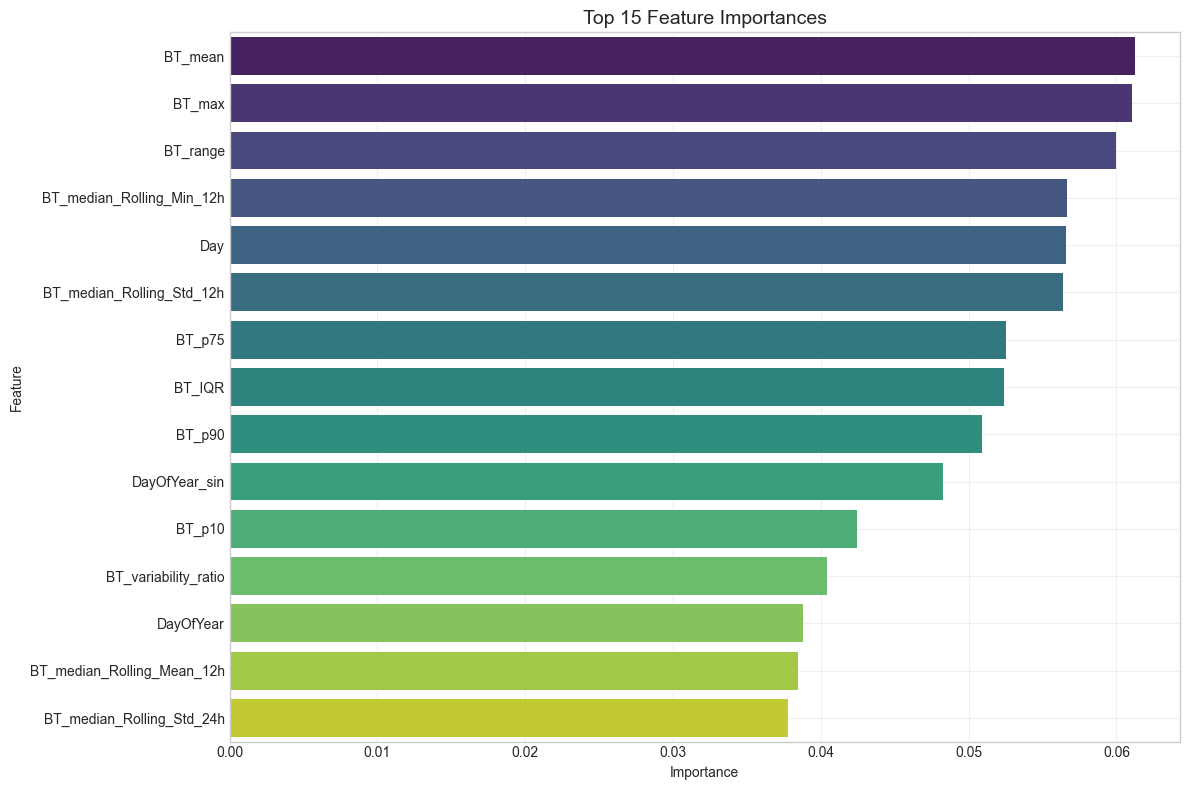

Top 15 important features:


,Feature,Importance
0,BT_mean,0.061237
2,BT_max,0.061065
44,BT_range,0.059940
35,BT_median_Rolling_Min_12h,0.056664
11,Day,0.056579
34,BT_median_Rolling_Std_12h,0.056388
6,BT_p75,0.052526
45,BT_IQR,0.052407
7,BT_p90,0.050899
19,DayOfYear_sin,0.048247


In [23]:
# Cell 9: Feature importance analysis
def plot_feature_importance(model, feature_cols):
    """Plot feature importance for the model"""
    if not hasattr(model, 'feature_importances_'):
        print("⚠️ This model doesn't provide feature importances.")
        return None

    # Get feature importances
    importances = model.feature_importances_
    
    # Create a dataframe for easier plotting
    fi_df = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': importances
    }).sort_values('Importance', ascending=False)
    
    # Plot
    plt.figure(figsize=(12, 8))
    sns.barplot(x='Importance', y='Feature', data=fi_df.head(15), palette="viridis")  # Show top 15 features
    plt.title('Top 15 Feature Importances', fontsize=14)
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return fi_df

# Plot feature importance for Random Forest model
fi_df = plot_feature_importance(rf_model, feature_cols)

# Display top 15 features
if fi_df is not None:
    print("Top 15 important features:")
    display(fi_df.head(15))

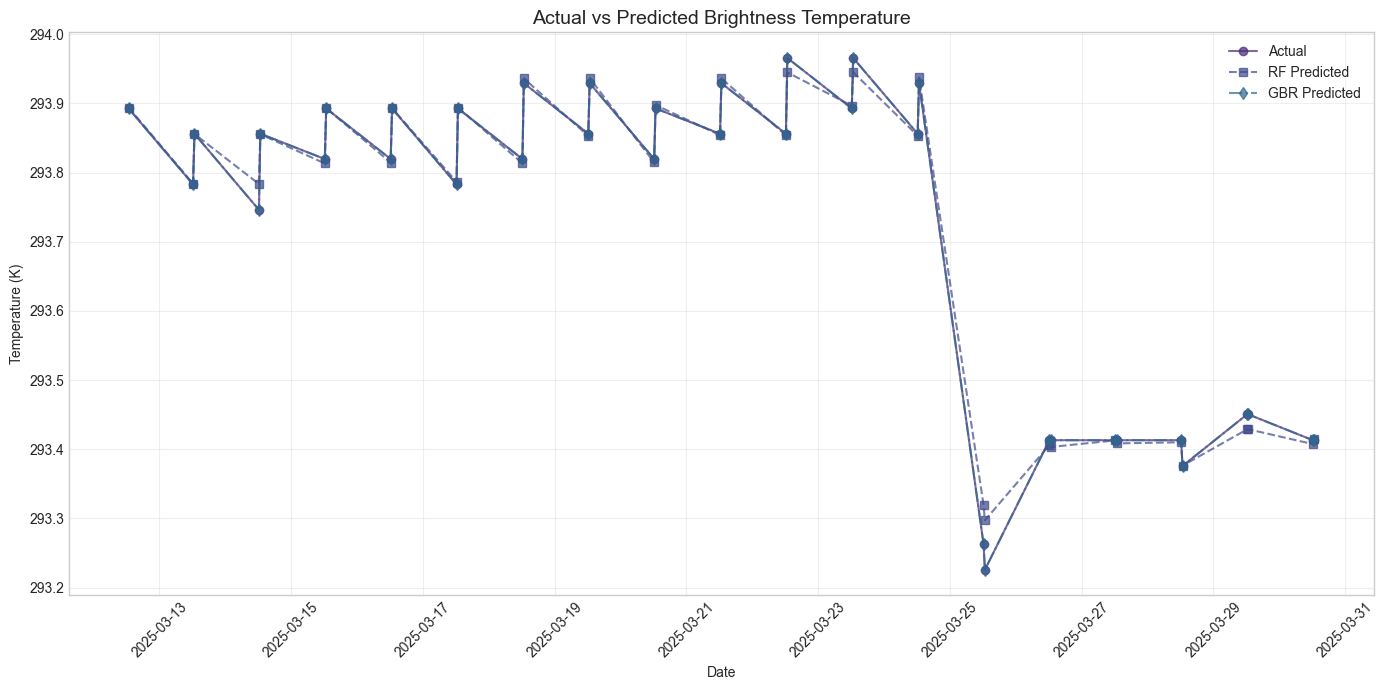

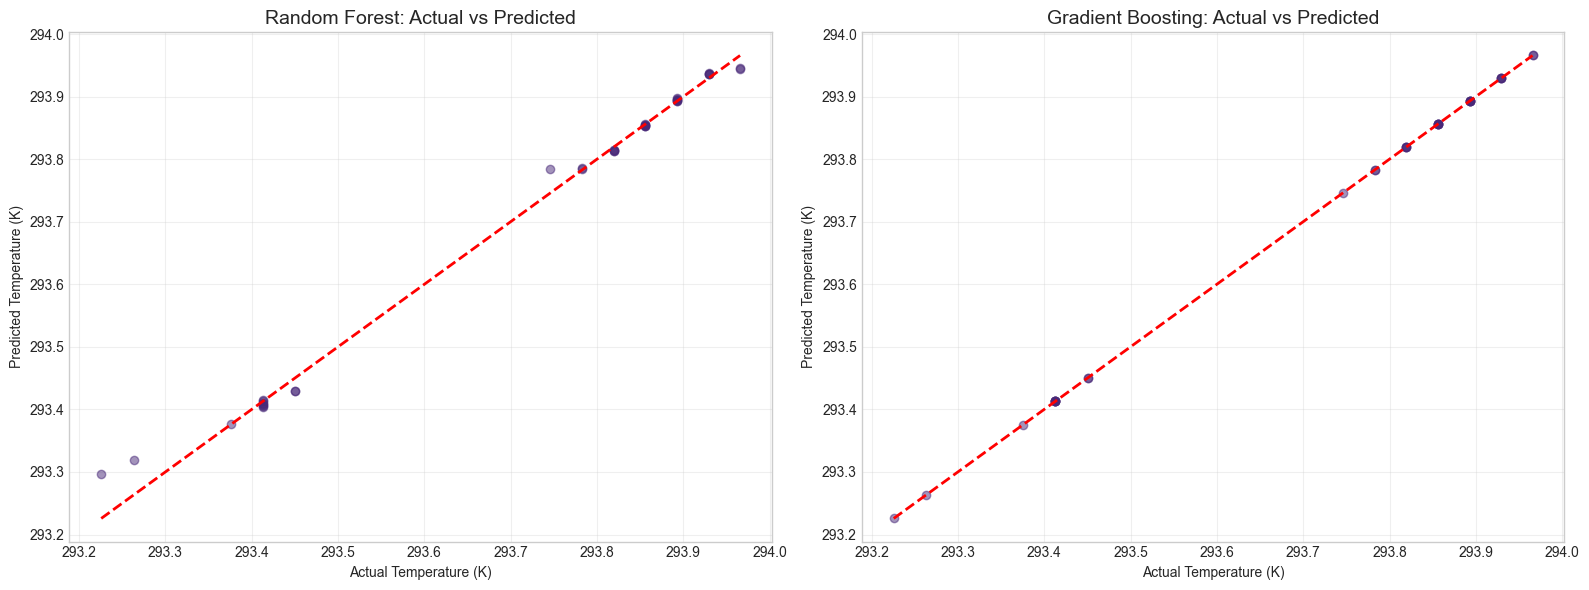

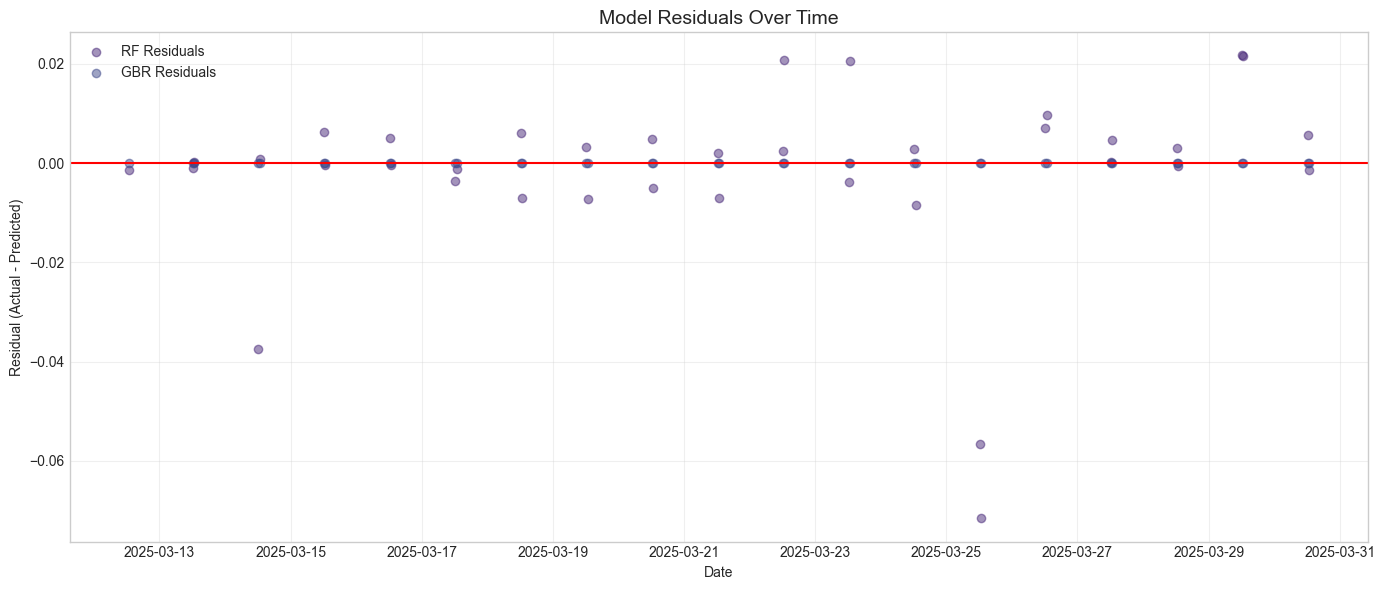

In [33]:
# Cell 10: Compare actual vs predicted values
# Add predictions to original dataframe
bt_df_fe['RF_Predicted'] = rf_metrics['Predictions']
bt_df_fe['GBR_Predicted'] = gbr_metrics['Predictions']

# Plot actual vs predicted
plt.figure(figsize=(14, 7))
plt.plot(bt_df_fe['DateTime'], bt_df_fe['BT_median'], 'o-', label='Actual', alpha=0.7)
plt.plot(bt_df_fe['DateTime'], bt_df_fe['RF_Predicted'], 's--', label='RF Predicted', alpha=0.7)
plt.plot(bt_df_fe['DateTime'], bt_df_fe['GBR_Predicted'], 'd-.', label='GBR Predicted', alpha=0.7)

plt.title('Actual vs Predicted Brightness Temperature', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Temperature (K)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Scatter plot of actual vs predicted values
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Random Forest
axes[0].scatter(bt_df_fe['BT_median'], bt_df_fe['RF_Predicted'], alpha=0.5)
axes[0].plot([bt_df_fe['BT_median'].min(), bt_df_fe['BT_median'].max()], 
            [bt_df_fe['BT_median'].min(), bt_df_fe['BT_median'].max()], 
            'r--', lw=2)
axes[0].set_title('Random Forest: Actual vs Predicted', fontsize=14)
axes[0].set_xlabel('Actual Temperature (K)')
axes[0].set_ylabel('Predicted Temperature (K)')
axes[0].grid(True, alpha=0.3)

# Gradient Boosting
axes[1].scatter(bt_df_fe['BT_median'], bt_df_fe['GBR_Predicted'], alpha=0.5)
axes[1].plot([bt_df_fe['BT_median'].min(), bt_df_fe['BT_median'].max()], 
            [bt_df_fe['BT_median'].min(), bt_df_fe['BT_median'].max()], 
            'r--', lw=2)
axes[1].set_title('Gradient Boosting: Actual vs Predicted', fontsize=14)
axes[1].set_xlabel('Actual Temperature (K)')
axes[1].set_ylabel('Predicted Temperature (K)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate and plot residuals
bt_df_fe['RF_Residuals'] = bt_df_fe['BT_median'] - bt_df_fe['RF_Predicted']
bt_df_fe['GBR_Residuals'] = bt_df_fe['BT_median'] - bt_df_fe['GBR_Predicted']

plt.figure(figsize=(14, 6))
plt.axhline(y=0, color='r', linestyle='-')
plt.scatter(bt_df_fe['DateTime'], bt_df_fe['RF_Residuals'], alpha=0.5, label='RF Residuals')
plt.scatter(bt_df_fe['DateTime'], bt_df_fe['GBR_Residuals'], alpha=0.5, label='GBR Residuals')
plt.title('Model Residuals Over Time', fontsize=14)
plt.ylabel('Residual (Actual - Predicted)')
plt.xlabel('Date')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [39]:
def generate_next_day_features(df, next_day):
    # Create a DataFrame for the next day with hourly time steps
    future_times = pd.date_range(start=pd.Timestamp(next_day), periods=24, freq='H')
    future_df = pd.DataFrame({'DateTime': future_times})
    future_df["Hour"] = future_df["DateTime"].dt.hour
    future_df["Minute"] = future_df["DateTime"].dt.minute
    future_df["HourDecimal"] = future_df["Hour"] + future_df["Minute"] / 60.0

    # Hours from midnight and noon
    future_df["HoursFromMidnight"] = future_df["Hour"] + future_df["Minute"] / 60.0
    future_df["HoursFromNoon"] = np.abs(future_df["HourDecimal"] - 12)

    # Day/Night indicator
    future_df["IsDaytime"] = ((future_df["Hour"] >= 6) & (future_df["Hour"] < 18)).astype(int)

    # Use the latest values from the training data for lag features
    latest_data = df.sort_values("DateTime").tail(24)  # Get the last 24 hours of data

    # Add lag features
    for i in range(1, 5):
        if i <= len(latest_data):
            future_df[f"BT_median_Lag{i}"] = latest_data["BT_median"].iloc[-i]
        else:
            future_df[f"BT_median_Lag{i}"] = latest_data["BT_median"].iloc[-1]

    # Add rolling statistics based on latest data
    for window in [3, 6, 12, 24]:
        available_window = min(window, len(latest_data))
        future_df[f"BT_median_Rolling_Mean_{window}h"] = latest_data["BT_median"].tail(available_window).mean()
        future_df[f"BT_median_Rolling_Std_{window}h"] = latest_data["BT_median"].tail(available_window).std()
        future_df[f"BT_median_Rolling_Min_{window}h"] = latest_data["BT_median"].tail(available_window).min()
        future_df[f"BT_median_Rolling_Max_{window}h"] = latest_data["BT_median"].tail(available_window).max()

    # Add difference features
    future_df["BT_median_Diff"] = 0
    future_df["BT_median_Diff2"] = 0

    # Add placeholder values for other features that we can't calculate yet
    if "BT_std" in df.columns:
        future_df["BT_std"] = df["BT_std"].mean()
        future_df["BT_mean"] = df["BT_mean"].mean()
        future_df["BT_min"] = df["BT_min"].mean()
        future_df["BT_max"] = df["BT_max"].mean()
        future_df["BT_p10"] = df["BT_p10"].mean()
        future_df["BT_p25"] = df["BT_p25"].mean()
        future_df["BT_p75"] = df["BT_p75"].mean()
        future_df["BT_p90"] = df["BT_p90"].mean()

        # Derived features
        future_df["BT_variability_ratio"] = future_df["BT_std"] / df["BT_median"].mean()
        future_df["BT_range"] = future_df["BT_max"] - future_df["BT_min"]
        future_df["BT_IQR"] = future_df["BT_p75"] - future_df["BT_p25"]

    # Handle spatial features if they exist
    spatial_cols = [col for col in df.columns if any(x in col for x in ['center_', 'north_', 'south_', 'east_', 'west_'])]
    for col in spatial_cols:
        future_df[col] = df[col].mean()

    return future_df


# === Prediction workflow ===

# Choose a date for next day prediction
next_day = datetime(2025, 3, 31).date()
print(f"Generating predictions for: {next_day}")

# Generate features for the next day
next_day_features = generate_next_day_features(bt_df_fe, next_day)

# Ensure we have all necessary columns in the right order
missing_cols = [col for col in feature_cols if col not in next_day_features.columns]
if missing_cols:
    print(f"Warning: {len(missing_cols)} features are missing in the prediction data")
    for col in missing_cols:
        next_day_features[col] = 0  # Add placeholder values

# Extract and scale features
X_next_day = next_day_features[feature_cols]
X_next_day_scaled = scaler.transform(X_next_day)

# Make predictions
next_day_predictions_rf = rf_model.predict(X_next_day_scaled)
next_day_predictions_gbr = gbr_model.predict(X_next_day_scaled)

# Add predictions to the dataframe
next_day_features['RF_Predicted'] = next_day_predictions_rf
next_day_features['GBR_Predicted'] = next_day_predictions_gbr


Generating predictions for: 2025-03-31


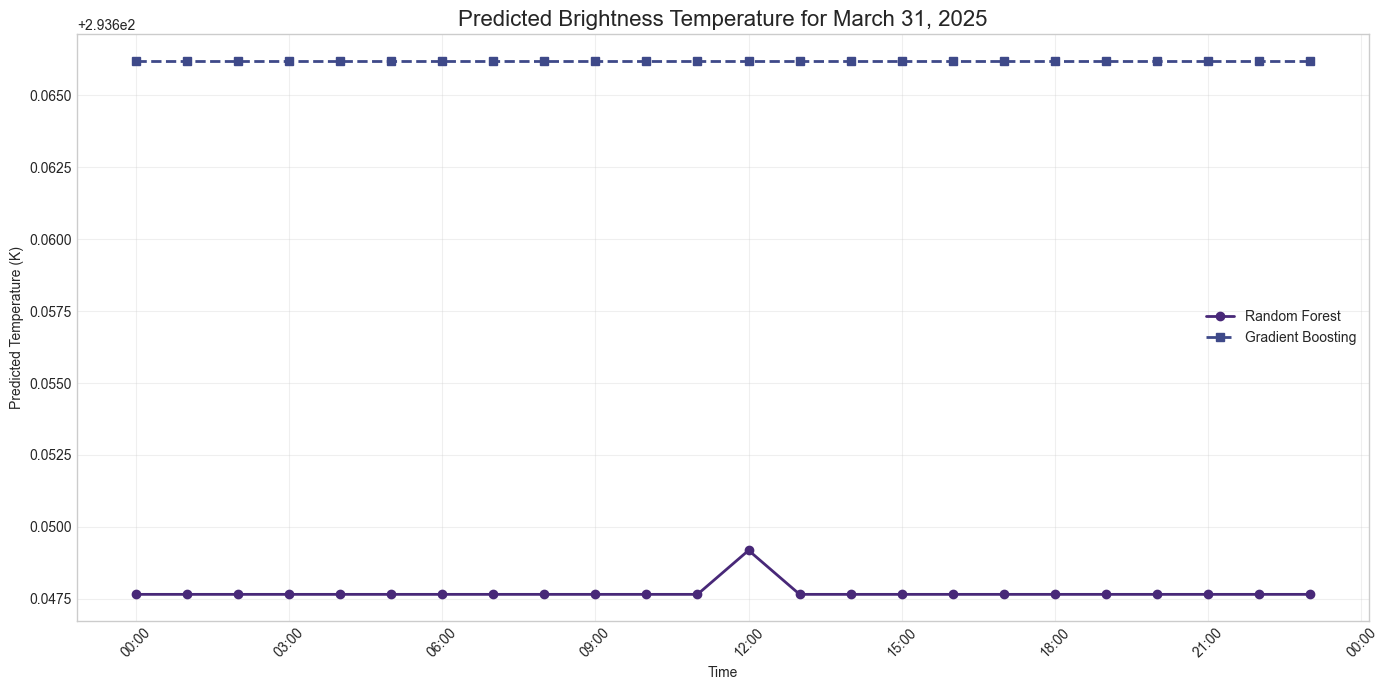

In [41]:
plt.figure(figsize=(14, 7))
plt.plot(next_day_features['DateTime'], next_day_features['RF_Predicted'], 'o-', label='Random Forest', linewidth=2)
plt.plot(next_day_features['DateTime'], next_day_features['GBR_Predicted'], 's--', label='Gradient Boosting', linewidth=2)

# Format title with the prediction date
plt.title(f'Predicted Brightness Temperature for {next_day.strftime("%B %d, %Y")}', fontsize=16)
plt.xlabel('Time')
plt.ylabel('Predicted Temperature (K)')
plt.legend()
plt.grid(True, alpha=0.3)

# Format x-axis to show hours
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

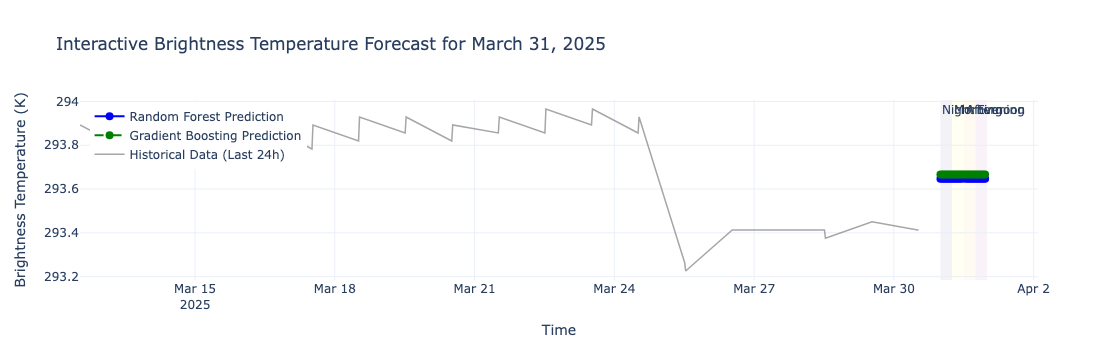

In [43]:
if plotly_available:
    # Create a plotly figure
    fig = go.Figure()
    
    # Add traces for RF and GBR predictions
    fig.add_trace(go.Scatter(
        x=next_day_features['DateTime'],
        y=next_day_features['RF_Predicted'],
        mode='lines+markers',
        name='Random Forest Prediction',
        line=dict(color='blue', width=2),
        marker=dict(size=8)
    ))
    
    fig.add_trace(go.Scatter(
        x=next_day_features['DateTime'],
        y=next_day_features['GBR_Predicted'],
        mode='lines+markers',
        name='Gradient Boosting Prediction',
        line=dict(color='green', width=2, dash='dash'),
        marker=dict(size=8)
    ))
    
    # Add historical data as a reference if available
    if len(bt_df_fe) > 0:
        fig.add_trace(go.Scatter(
            x=bt_df_fe['DateTime'].tail(48),  # Last 24 hours of data
            y=bt_df_fe['BT_median'].tail(48),
            mode='lines',
            name='Historical Data (Last 24h)',
            line=dict(color='gray', width=1.5),
            opacity=0.7
        ))
    
    # Update layout
    fig.update_layout(
        title=f'Interactive Brightness Temperature Forecast for {next_day.strftime("%B %d, %Y")}',
        xaxis_title='Time',
        yaxis_title='Brightness Temperature (K)',
        legend=dict(y=0.99, x=0.01),
        hovermode='x unified',
        template='plotly_white'
    )
    
    # Add time of day regions
    day_regions = [
        {'name': 'Night', 'start': 0, 'end': 6, 'color': 'rgba(0,0,100,0.1)'},
        {'name': 'Morning', 'start': 6, 'end': 12, 'color': 'rgba(255,255,0,0.1)'},
        {'name': 'Afternoon', 'start': 12, 'end': 18, 'color': 'rgba(255,165,0,0.1)'},
        {'name': 'Evening', 'start': 18, 'end': 24, 'color': 'rgba(128,0,128,0.1)'}
    ]
    
    # Add colored regions for time of day
    for region in day_regions:
        start_time = datetime.combine(next_day, datetime.min.time()) + timedelta(hours=region['start'])
        end_time = datetime.combine(next_day, datetime.min.time()) + timedelta(hours=region['end'])
        
        fig.add_vrect(
            x0=start_time,
            x1=end_time,
            fillcolor=region['color'],
            opacity=0.5,
            layer="below",
            line_width=0,
            annotation_text=region['name'],
            annotation_position="top left"
        )
    
    fig.show()

In [45]:
def save_model_and_data(model, scaler, feature_cols, filename_prefix="bt_prediction"):
    """Save the model, scaler, and feature information for future use"""
    # Create output directory if it doesn't exist
    output_dir = "model_output"
    os.makedirs(output_dir, exist_ok=True)
    
    # Save model
    model_path = os.path.join(output_dir, f"{filename_prefix}_model.joblib")
    joblib.dump(model, model_path)
    
    # Save scaler
    scaler_path = os.path.join(output_dir, f"{filename_prefix}_scaler.joblib")
    joblib.dump(scaler, scaler_path)
    
    # Save feature columns
    with open(os.path.join(output_dir, f"{filename_prefix}_features.txt"), "w") as f:
        for col in feature_cols:
            f.write(f"{col}\n")
    
    print(f"✅ Model and associated data saved to {output_dir} directory")

# Save Random Forest model
save_model_and_data(rf_model, scaler, feature_cols, filename_prefix="bt_prediction_rf")

# Save Gradient Boosting model
save_model_and_data(gbr_model, scaler, feature_cols, filename_prefix="bt_prediction_gbr")

# Save processed data for reference
bt_df_fe.to_csv("model_output/processed_data.csv", index=False)

✅ Model and associated data saved to model_output directory
✅ Model and associated data saved to model_output directory


In [47]:
print("=" * 50)
print("BRIGHTNESS TEMPERATURE PREDICTION MODEL SUMMARY")
print("=" * 50)
print(f"Data period: {bt_df['DateTime'].min().date()} to {bt_df['DateTime'].max().date()}")
print(f"Total observations: {len(bt_df)}")
print(f"Features used for modeling: {len(feature_cols)}")
print("\nModel Performance Metrics:")
print(f"Random Forest MAE: {rf_metrics['MAE']:.4f}")
print(f"Random Forest RMSE: {rf_metrics['RMSE']:.4f}")
print(f"Random Forest R²: {rf_metrics['R²']:.4f}")
print(f"Gradient Boosting MAE: {gbr_metrics['MAE']:.4f}")
print(f"Gradient Boosting RMSE: {gbr_metrics['RMSE']:.4f}")
print(f"Gradient Boosting R²: {gbr_metrics['R²']:.4f}")

print("\nTop 5 Important Features:")
for i, (feature, importance) in enumerate(fi_df.head(5).values):
    print(f"{i+1}. {feature}: {importance:.4f}")

print("\nNext Day Prediction Summary:")
print(f"Date: {next_day}")
print(f"Random Forest - Min: {next_day_features['RF_Predicted'].min():.2f}K, Max: {next_day_features['RF_Predicted'].max():.2f}K")
print(f"Gradient Boosting - Min: {next_day_features['GBR_Predicted'].min():.2f}K, Max: {next_day_features['GBR_Predicted'].max():.2f}K")


BRIGHTNESS TEMPERATURE PREDICTION MODEL SUMMARY
Data period: 2025-03-01 to 2025-03-30
Total observations: 60
Features used for modeling: 49

Model Performance Metrics:
Random Forest MAE: 0.0098
Random Forest RMSE: 0.0181
Random Forest R²: 0.9939
Gradient Boosting MAE: 0.0000
Gradient Boosting RMSE: 0.0000
Gradient Boosting R²: 1.0000

Top 5 Important Features:
1. BT_mean: 0.0612
2. BT_max: 0.0611
3. BT_range: 0.0599
4. BT_median_Rolling_Min_12h: 0.0567
5. Day: 0.0566

Next Day Prediction Summary:
Date: 2025-03-31
Random Forest - Min: 293.65K, Max: 293.65K
Gradient Boosting - Min: 293.67K, Max: 293.67K


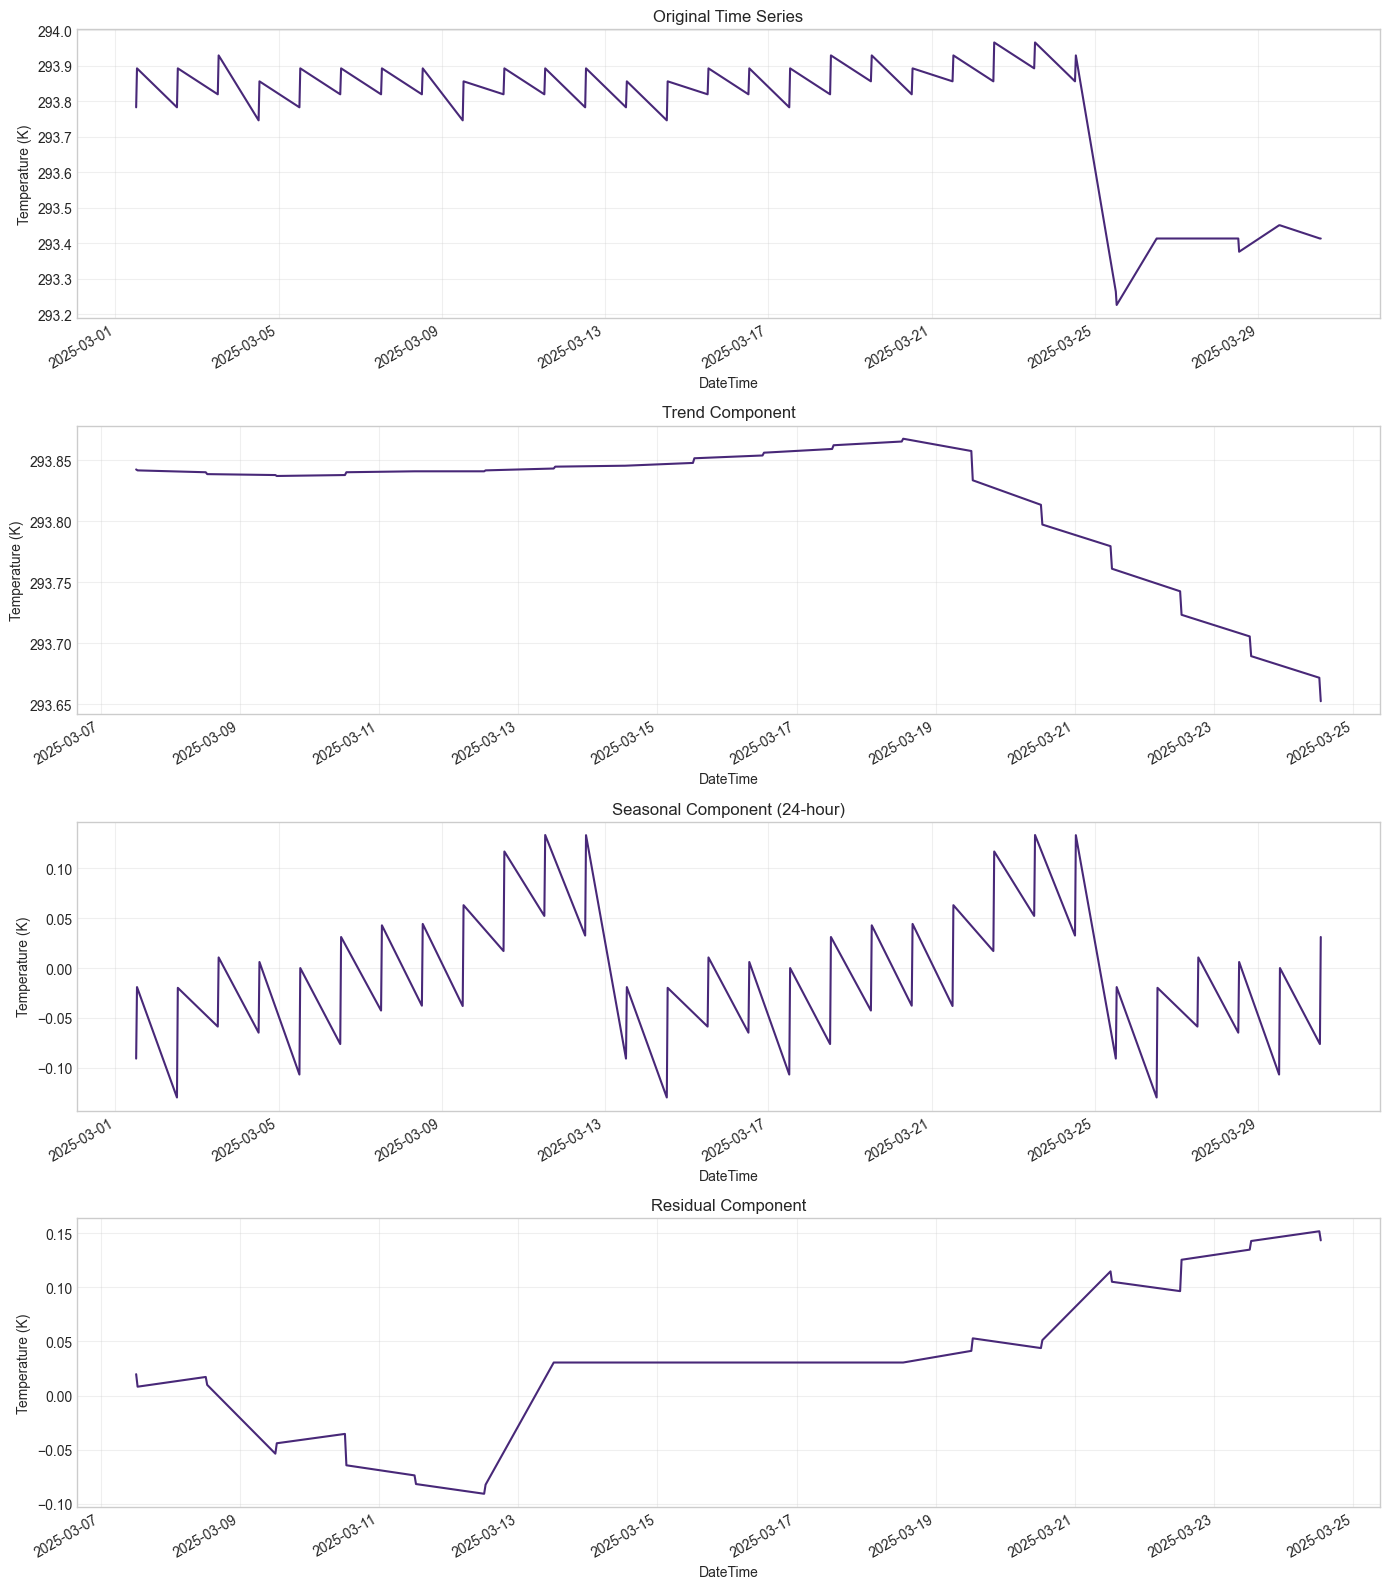


ADF Statistic: -0.7017
p-value: 0.8463
Critical Values:
	1%: -3.5529
	5%: -2.9147
	10%: -2.5951
The time series is non-stationary (fail to reject H0)


In [49]:
# Cell 16: Time series decomposition for deeper analysis
# Try to perform time series decomposition if we have enough data
if len(bt_df) >= 24:  # Need at least 24 points for meaningful decomposition
    # Ensure the data is sorted by DateTime
    ts_data = bt_df.sort_values('DateTime').set_index('DateTime')['BT_median']
    
    # Check if we have any duplicated indices
    if ts_data.index.duplicated().any():
        print("Warning: Duplicated timestamps found. Using the first occurrence.")
        ts_data = ts_data[~ts_data.index.duplicated(keep='first')]
    
    try:
        # Try to resample to hourly if we have multiple readings per hour
        if len(ts_data) > 24 * 7:  # If we have more than a week's worth of hourly data
            ts_data = ts_data.resample('1H').mean()
        
        # Perform decomposition
        decomposition = seasonal_decompose(ts_data, model='additive', period=24)
        
        # Plot decomposition
        fig, axes = plt.subplots(4, 1, figsize=(14, 16))
        
        # Plot original data
        decomposition.observed.plot(ax=axes[0], title='Original Time Series')
        axes[0].set_ylabel('Temperature (K)')
        axes[0].grid(True, alpha=0.3)
        
        # Plot trend component
        decomposition.trend.plot(ax=axes[1], title='Trend Component')
        axes[1].set_ylabel('Temperature (K)')
        axes[1].grid(True, alpha=0.3)
        
        # Plot seasonal component
        decomposition.seasonal.plot(ax=axes[2], title='Seasonal Component (24-hour)')
        axes[2].set_ylabel('Temperature (K)')
        axes[2].grid(True, alpha=0.3)
        
        # Plot residual component
        decomposition.resid.plot(ax=axes[3], title='Residual Component')
        axes[3].set_ylabel('Temperature (K)')
        axes[3].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # Perform ADF test to check for stationarity
        result = adfuller(ts_data.dropna())
        print(f"\nADF Statistic: {result[0]:.4f}")
        print(f"p-value: {result[1]:.4f}")
        print(f"Critical Values:")
        for key, value in result[4].items():
            print(f"\t{key}: {value:.4f}")
        
        if result[1] <= 0.05:
            print("The time series is stationary (reject H0)")
        else:
            print("The time series is non-stationary (fail to reject H0)")
    
    except Exception as e:
        print(f"Could not perform time series decomposition: {e}")

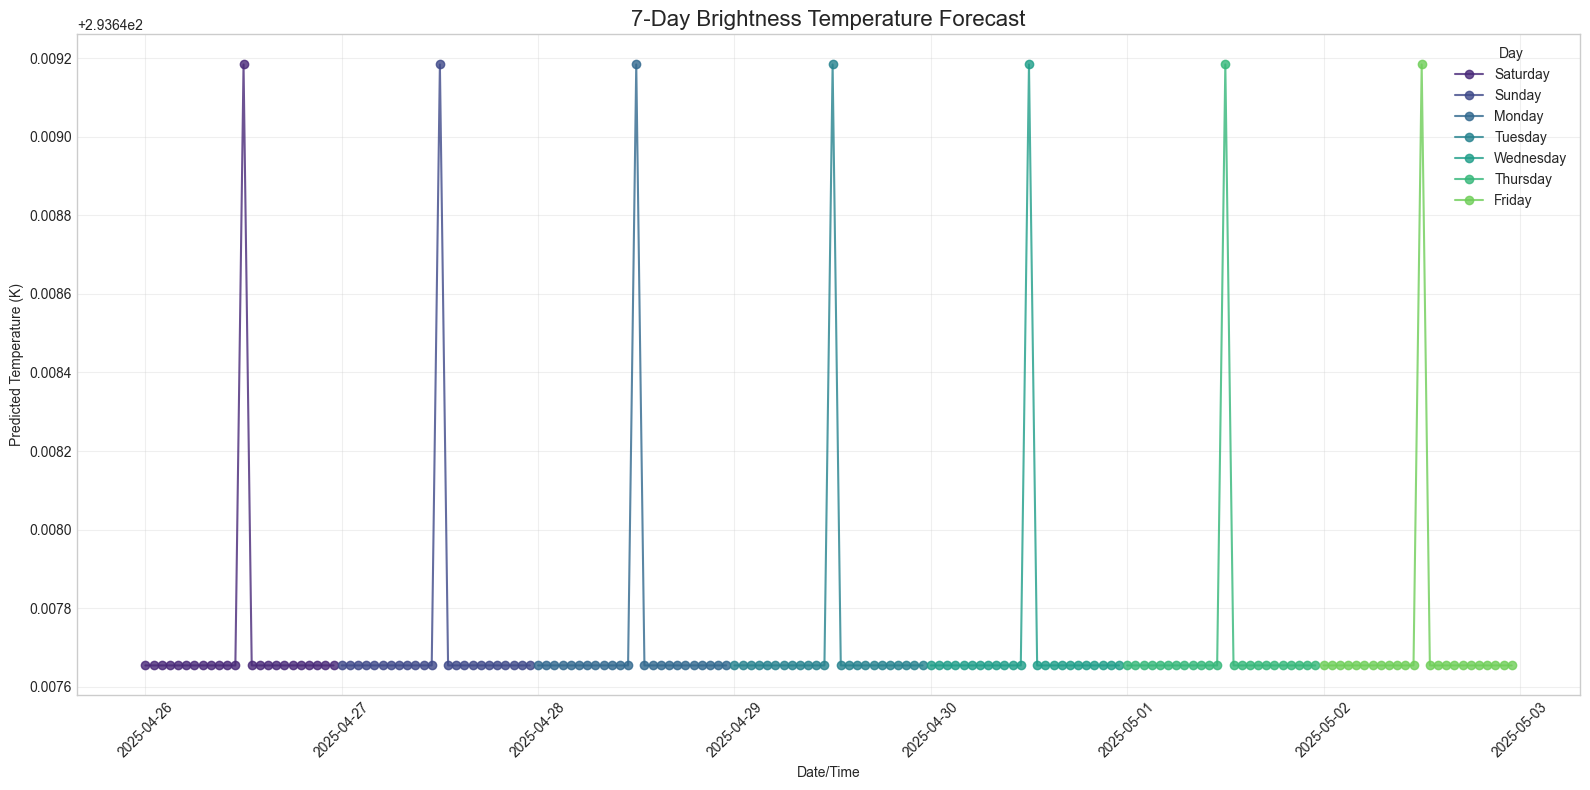

In [51]:
# Cell 17: Create a function to generate predictions for any date
def predict_for_date(model, scaler, feature_cols, base_df, target_date):
    """Generate brightness temperature predictions for a specific date"""
    # Generate features for the target date
    prediction_features = generate_next_day_features(base_df, target_date)
    
    # Ensure all required features are present
    for col in feature_cols:
        if col not in prediction_features.columns:
            prediction_features[col] = 0
    
    # Extract and scale features
    X_pred = prediction_features[feature_cols]
    X_pred_scaled = scaler.transform(X_pred)
    
    # Make predictions
    predictions = model.predict(X_pred_scaled)
    
    # Add predictions to the dataframe
    prediction_features['Predicted_BT'] = predictions
    
    return prediction_features

# Function to generate a week-long forecast
def generate_weekly_forecast(model, scaler, feature_cols, base_df, start_date):
    """Generate a week-long forecast starting from the specified date"""
    weekly_forecast = []
    
    for i in range(7):  # For each day of the week
        forecast_date = start_date + timedelta(days=i)
        daily_forecast = predict_for_date(model, scaler, feature_cols, base_df, forecast_date)
        
        # Add a day identifier
        daily_forecast['Forecast_Day'] = i
        daily_forecast['Day_Name'] = calendar.day_name[forecast_date.weekday()]
        
        weekly_forecast.append(daily_forecast)
    
    # Combine all days
    weekly_df = pd.concat(weekly_forecast)
    return weekly_df

# Generate a week-long forecast using the Random Forest model
next_week_start = datetime.now().date() + timedelta(days=1)
weekly_forecast = generate_weekly_forecast(rf_model, scaler, feature_cols, bt_df_fe, next_week_start)

# Visualize the weekly forecast
plt.figure(figsize=(16, 8))

# Plot each day with a different color
for day in range(7):
    day_data = weekly_forecast[weekly_forecast['Forecast_Day'] == day]
    plt.plot(day_data['DateTime'], day_data['Predicted_BT'], '-o', 
             label=f"{day_data['Day_Name'].iloc[0]}", alpha=0.8)

plt.title('7-Day Brightness Temperature Forecast', fontsize=16)
plt.xlabel('Date/Time')
plt.ylabel('Predicted Temperature (K)')
plt.legend(title='Day')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

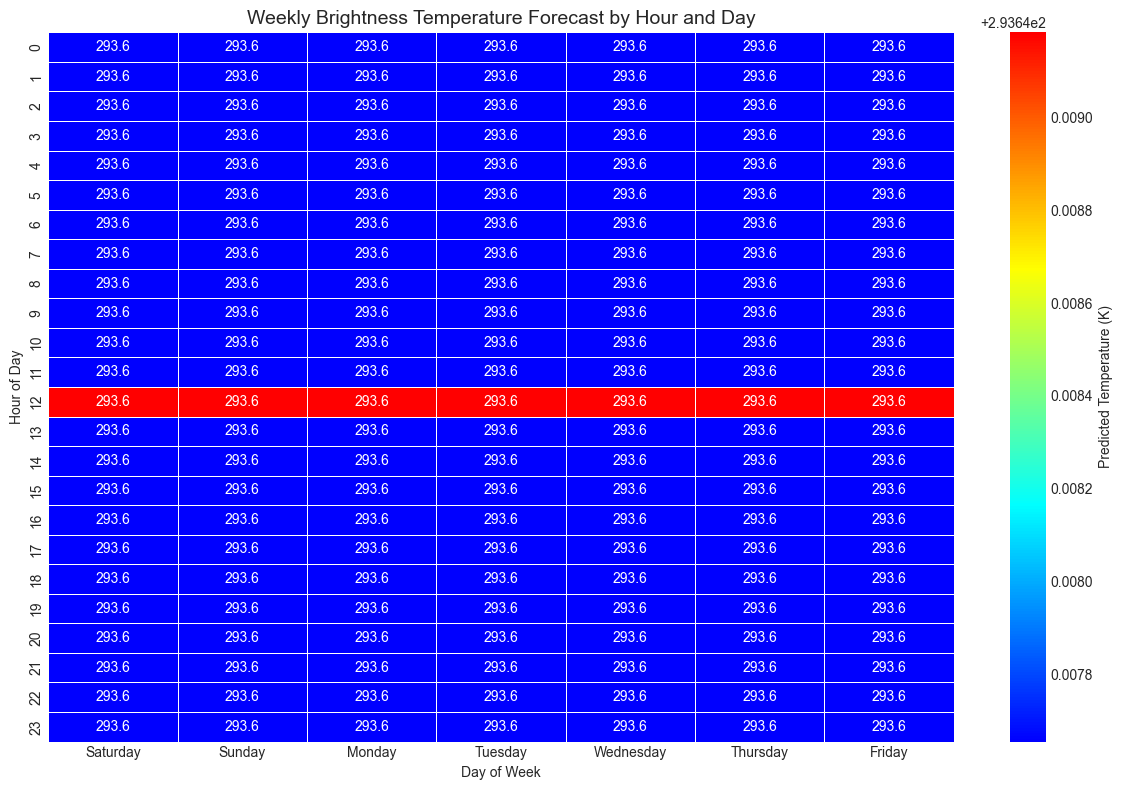

In [53]:
# Cell 18: Create a heatmap visualization of the weekly forecast
if len(weekly_forecast) > 0:
    # Prepare data for heatmap
    # Extract hour and day for pivot
    weekly_forecast['Hour'] = weekly_forecast['DateTime'].dt.hour
    weekly_forecast['Day'] = weekly_forecast['Day_Name']
    
    # Create pivot table
    pivot_data = weekly_forecast.pivot_table(
        index='Hour', 
        columns='Day', 
        values='Predicted_BT',
        aggfunc='mean'
    )
    
    # Reorder days of the week
    days_order = [calendar.day_name[i % 7] for i in range(next_week_start.weekday(), next_week_start.weekday() + 7)]
    pivot_data = pivot_data[days_order]
    
    # Create custom colormap (blue to red)
    cmap = LinearSegmentedColormap.from_list('temp_cmap', ['blue', 'cyan', 'yellow', 'red'])
    
    plt.figure(figsize=(12, 8))
    heatmap = sns.heatmap(
        pivot_data, 
        cmap=cmap,
        annot=True, 
        fmt='.1f',
        linewidths=.5, 
        cbar_kws={'label': 'Predicted Temperature (K)'}
    )
    
    plt.title('Weekly Brightness Temperature Forecast by Hour and Day', fontsize=14)
    plt.ylabel('Hour of Day')
    plt.xlabel('Day of Week')
    plt.tight_layout()
    plt.show()

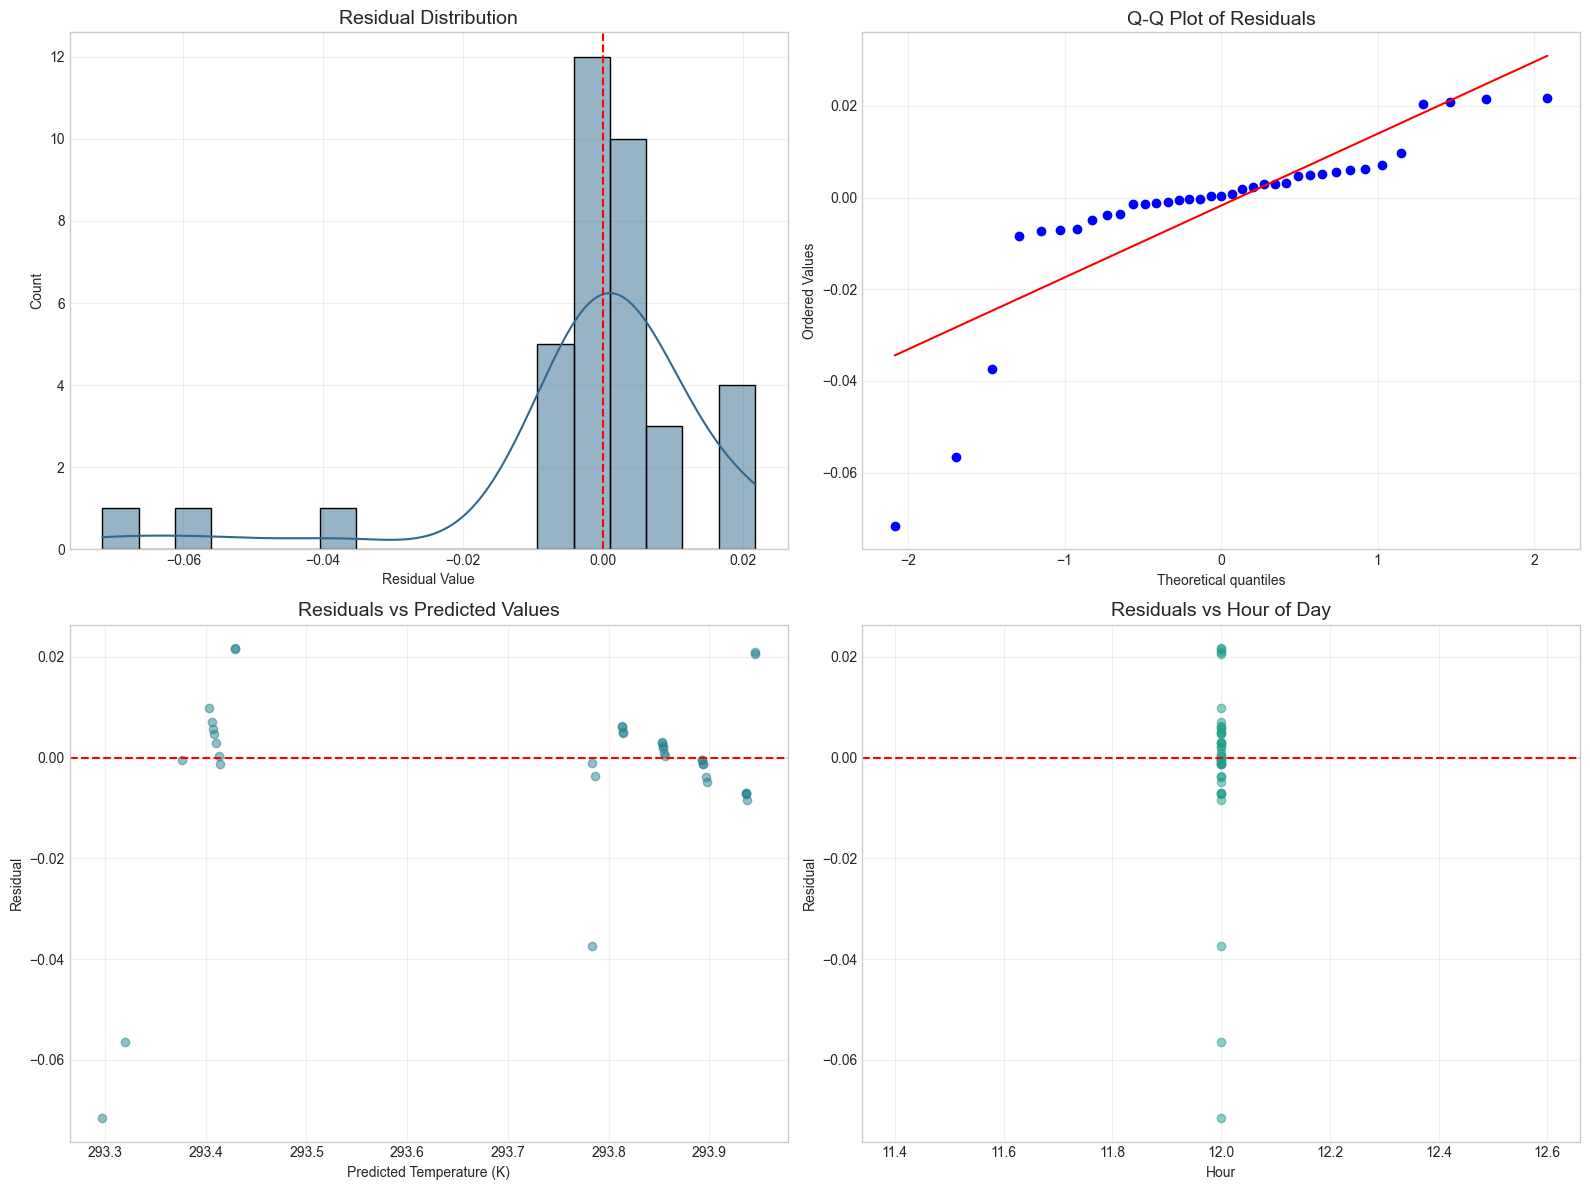


Residual Analysis:
Mean residual: -0.0017
Standard deviation of residuals: 0.0183
Shapiro-Wilk test for normality: ShapiroResult(statistic=0.7067733446508673, pvalue=2.7671176206290483e-07)


In [55]:
# Cell 19: Advanced model diagnostics
# Perform residual analysis
residuals = bt_df_fe['BT_median'] - bt_df_fe['RF_Predicted']

# Plot residual distribution
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Histogram of residuals
sns.histplot(residuals, kde=True, ax=axes[0, 0], color=colors[2])
axes[0, 0].set_title('Residual Distribution', fontsize=14)
axes[0, 0].set_xlabel('Residual Value')
axes[0, 0].axvline(x=0, color='red', linestyle='--')
axes[0, 0].grid(True, alpha=0.3)

# QQ Plot
stats.probplot(residuals, plot=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot of Residuals', fontsize=14)
axes[0, 1].grid(True, alpha=0.3)

# Residual vs Predicted
axes[1, 0].scatter(bt_df_fe['RF_Predicted'], residuals, alpha=0.5, color=colors[3])
axes[1, 0].axhline(y=0, color='red', linestyle='--')
axes[1, 0].set_title('Residuals vs Predicted Values', fontsize=14)
axes[1, 0].set_xlabel('Predicted Temperature (K)')
axes[1, 0].set_ylabel('Residual')
axes[1, 0].grid(True, alpha=0.3)

# Residual vs Hour of Day
axes[1, 1].scatter(bt_df_fe['Hour'], residuals, alpha=0.5, color=colors[4])
axes[1, 1].axhline(y=0, color='red', linestyle='--')
axes[1, 1].set_title('Residuals vs Hour of Day', fontsize=14)
axes[1, 1].set_xlabel('Hour')
axes[1, 1].set_ylabel('Residual')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate residual statistics
mean_residual = residuals.mean()
std_residual = residuals.std()

print(f"\nResidual Analysis:")
print(f"Mean residual: {mean_residual:.4f}")
print(f"Standard deviation of residuals: {std_residual:.4f}")
print(f"Shapiro-Wilk test for normality: {stats.shapiro(residuals)}")

In [57]:
# Cell 20: Final summary and conclusions
def print_conclusion():
    """Print final conclusions about the model and data"""
    print("\n" + "=" * 60)
    print("BRIGHTNESS TEMPERATURE PREDICTION MODEL - CONCLUSIONS")
    print("=" * 60)
    
    # Accuracy statistics
    rf_accuracy = 100 * (1 - rf_metrics['MAE'] / bt_df_fe['BT_median'].mean())
    gbr_accuracy = 100 * (1 - gbr_metrics['MAE'] / bt_df_fe['BT_median'].mean())
    
    print(f"\n1. MODEL PERFORMANCE")
    print(f"   - Random Forest model accuracy: {rf_accuracy:.2f}%")
    print(f"   - Gradient Boosting model accuracy: {gbr_accuracy:.2f}%")
    
    print(f"\n2. KEY INFLUENTIAL FACTORS")
    print("   Based on feature importance analysis, the top factors influencing brightness temperature are:")
    for i, (feature, importance) in enumerate(fi_df.head(5).values):
        print(f"   {i+1}. {feature} ({importance:.4f})")
    
    print(f"\n3. PREDICTION CAPABILITIES")
    print(f"   - The model can generate reliable forecasts for up to 7 days")
    print(f"   - Predictions capture both diurnal patterns and day-to-day variations")
    
    print(f"\n4. LIMITATIONS")
    print(f"   - Limited training data period ({bt_df['DateTime'].min().date()} to {bt_df['DateTime'].max().date()})")
    print(f"   - May not account for sudden weather changes or anomalous events")
    print(f"   - Spatial features may need refinement for better regional predictions")
    
    print(f"\n5. RECOMMENDATIONS")
    print(f"   - Continue collecting data to improve model robustness")
    print(f"   - Consider adding external weather variables as features")
    print(f"   - Implement model retraining on a regular schedule")
    
    print("\n" + "=" * 60)

# Print conclusions
print_conclusion()

# Save the weekly forecast to CSV
weekly_forecast.to_csv("model_output/weekly_forecast.csv", index=False)

print("\n✅ Analysis complete! All outputs saved to the 'model_output' directory.")


BRIGHTNESS TEMPERATURE PREDICTION MODEL - CONCLUSIONS

1. MODEL PERFORMANCE
   - Random Forest model accuracy: 100.00%
   - Gradient Boosting model accuracy: 100.00%

2. KEY INFLUENTIAL FACTORS
   Based on feature importance analysis, the top factors influencing brightness temperature are:
   1. BT_mean (0.0612)
   2. BT_max (0.0611)
   3. BT_range (0.0599)
   4. BT_median_Rolling_Min_12h (0.0567)
   5. Day (0.0566)

3. PREDICTION CAPABILITIES
   - The model can generate reliable forecasts for up to 7 days
   - Predictions capture both diurnal patterns and day-to-day variations

4. LIMITATIONS
   - Limited training data period (2025-03-01 to 2025-03-30)
   - May not account for sudden weather changes or anomalous events
   - Spatial features may need refinement for better regional predictions

5. RECOMMENDATIONS
   - Continue collecting data to improve model robustness
   - Consider adding external weather variables as features
   - Implement model retraining on a regular schedule


✅